# Sanity Check

## reward distributions

In [2]:
import os
import json
import glob
import math
from typing import List, Dict, Any, Tuple, Union
from dataclasses import dataclass
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def _read_json_any(path: str) -> List[Dict[str, Any]]:
    """Load either JSON array file or JSONL (one JSON per line)."""
    with open(path, "r", encoding="utf-8") as f:
        text = f.read().strip()
    if not text:
        return []
    # Try JSON array/dict
    try:
        obj = json.loads(text)
        if isinstance(obj, list):
            return obj
        elif isinstance(obj, dict):
            return [obj]
    except json.JSONDecodeError:
        pass
    # Fallback: JSON Lines
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                rows.append(json.loads(line))
            except json.JSONDecodeError:
                continue
    return rows

def load_datasets(paths: List[str]) -> List[Dict[str, Any]]:
    files: List[str] = []
    for p in paths:
        files.extend(glob.glob(p))
    files = sorted(set(files))
    all_rows: List[Dict[str, Any]] = []
    for fp in files:
        try:
            rows = _read_json_any(fp)
            all_rows.extend(rows)
        except Exception as e:
            print(f"[WARN] Failed to read {fp}: {e}")
    return all_rows

def filter_outliers(df_steps: pd.DataFrame, abs_max: float | None = None,
                    bounds: dict[str, tuple[float | None, float | None]] | None = None) -> pd.DataFrame:
    if df_steps.empty:
        return df_steps

    mask = pd.Series(True, index=df_steps.index)

    # 절대값 기반 필터
    if abs_max is not None:
        mask &= df_steps["value"].abs() <= float(abs_max)

    # 메트릭별 범위 기반 필터
    if bounds:
        # bounds를 DataFrame으로 변환 후 merge
        bdf = pd.DataFrame(
            [(m, lo, hi) for m, (lo, hi) in bounds.items()],
            columns=["metric", "lo", "hi"]
        )
        merged = df_steps.merge(bdf, on="metric", how="left")
        # lo 조건
        lo_ok = merged["lo"].isna() | (merged["value"] >= merged["lo"])
        # hi 조건
        hi_ok = merged["hi"].isna() | (merged["value"] <= merged["hi"])
        mask &= (lo_ok & hi_ok).values

    out = df_steps[mask]
    dropped = len(df_steps) - len(out)
    if dropped > 0:
        print(f"[INFO] Outlier filter dropped {dropped} rows "
              f"({dropped/len(df_steps)*100:.2f}%). Kept {len(out)}.")
    else:
        print("[INFO] Outlier filter kept all rows.")
    return out

@dataclass
class StepRecord:
    sample_id: int
    step_idx: int
    metric: str
    value: float
    correct: int
    perturbation: str

def build_step_dataframe(
    samples: List[Dict[str, Any]],
    *,
    label_source: str = "correct_mask"   # <<< 기본값을 correct_mask로
) -> pd.DataFrame:
    records: List[StepRecord] = []

    for i, s in enumerate(samples):
        # ----- 라벨 소스: 오직 correct_mask만 우선 -----
        lab = None
        if label_source == "correct_mask" and isinstance(s.get("correct_mask"), list):
            lab = s["correct_mask"]
        elif isinstance(s.get("correct_mask"), list):
            lab = s["correct_mask"]

        perturb = s.get("perturbation", "")

        for metric in METRICS:
            vals = s.get(metric, None)
            if not isinstance(vals, list):
                continue
            for j, v in enumerate(vals):
                corr = -1
                if isinstance(lab, list) and j < len(lab):
                    corr = 1 if float(lab[j]) > 0.5 else 0

                records.append(StepRecord(
                    sample_id=i,
                    step_idx=j,
                    metric=metric,
                    value=float(v),
                    correct=corr,
                    perturbation=str(perturb) if perturb is not None else ""
                ))

    if not records:
        return pd.DataFrame(columns=["sample_id","step_idx","metric","value","correct","perturbation"])
    df = pd.DataFrame([r.__dict__ for r in records])
    cols = ["sample_id","step_idx","metric","value","correct","perturbation"]
    return df[cols]

def summarize_global(df_steps: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for metric in METRICS:
        sub = df_steps[df_steps["metric"] == metric]["value"].astype(float)
        if sub.empty:
            continue
        arr = sub.to_numpy()
        rows.append({
            "metric": metric,
            "count": int(arr.size),
            "mean": float(np.mean(arr)),
            "std": float(np.std(arr, ddof=1)) if arr.size > 1 else float("nan"),
            "var": float(np.var(arr, ddof=1)) if arr.size > 1 else float("nan"),
            "min": float(np.min(arr)),
            "p05": float(np.quantile(arr, 0.05)),
            "p25": float(np.quantile(arr, 0.25)),
            "median": float(np.quantile(arr, 0.50)),
            "p75": float(np.quantile(arr, 0.75)),
            "p95": float(np.quantile(arr, 0.95)),
            "max": float(np.max(arr)),
        })
    return pd.DataFrame(rows).set_index("metric") if rows else pd.DataFrame()

def _group_quantiles(g: pd.core.groupby.generic.SeriesGroupBy) -> pd.DataFrame:
    return pd.DataFrame({
        "count": g.size(),
        "mean": g.mean(),
        "std": g.std(ddof=1),
        "min": g.min(),
        "p25": g.quantile(0.25),
        "median": g.quantile(0.5),
        "p75": g.quantile(0.75),
        "max": g.max(),
    }).reset_index()

def summarize_per_sample(df_steps: pd.DataFrame) -> pd.DataFrame:
    if df_steps.empty:
        return pd.DataFrame()
    g = df_steps.groupby(["sample_id", "metric"])["value"]
    out = _group_quantiles(g).sort_values(["sample_id", "metric"]).reset_index(drop=True)
    return out

def summarize_per_step_index(df_steps: pd.DataFrame) -> pd.DataFrame:
    if df_steps.empty:
        return pd.DataFrame()
    g = df_steps.groupby(["step_idx", "metric"])["value"]
    out = _group_quantiles(g).sort_values(["step_idx", "metric"]).reset_index(drop=True)
    return out

def correlation_matrix_global(df_steps: pd.DataFrame) -> pd.DataFrame:
    """Global step-level correlation across metrics (inner-join on rows that have all metrics)."""
    if df_steps.empty:
        return pd.DataFrame()
    pivot = df_steps.pivot_table(index=["sample_id","step_idx"], columns="metric", values="value", aggfunc="mean")
    needed = [m for m in METRICS if m in pivot.columns]
    pivot = pivot.dropna(subset=needed, how="any")
    if pivot.empty:
        return pd.DataFrame()
    corr = pivot.corr(method="pearson")
    return corr

def per_sample_correlations(df_steps: pd.DataFrame) -> pd.DataFrame:
    """For each sample_id, compute pairwise Pearson correlations between metrics across steps."""
    if df_steps.empty:
        return pd.DataFrame(columns=["sample_id","n_steps_common",
                                     "corr_loo_shapley","corr_loo_margin","corr_shapley_margin"])
    rows = []
    for sid, sdf in df_steps.groupby("sample_id"):
        pivot = sdf.pivot_table(index="step_idx", columns="metric", values="value", aggfunc="mean")
        cols = [m for m in METRICS if m in pivot.columns]
        if len(cols) < 2:
            rows.append({"sample_id": sid, "n_steps_common": int(pivot.shape[0]),
                         "corr_loo_shapley": np.nan, "corr_loo_margin": np.nan, "corr_shapley_margin": np.nan})
            continue
        pivot = pivot.dropna(subset=cols, how="any")
        n = int(pivot.shape[0])
        def corr_safe(a, b):
            if a not in pivot.columns or b not in pivot.columns or n < 2:
                return np.nan
            try:
                return float(pivot[a].corr(pivot[b]))
            except Exception:
                return np.nan
        rows.append({
            "sample_id": sid,
            "n_steps_common": n,
            "corr_loo_shapley": corr_safe("mi_loo","mi_shapley"),
            "corr_loo_margin": corr_safe("mi_loo","mi_margin"),
            "corr_shapley_margin": corr_safe("mi_shapley","mi_margin"),
        })
    return pd.DataFrame(rows).sort_values("sample_id").reset_index(drop=True)

def ensure_dir(path: str):
    os.makedirs(path, exist_ok=True)

def plot_hist(df_steps: pd.DataFrame, metric: str, outdir: str) -> str:
    sub = df_steps[df_steps["metric"] == metric]["value"].astype(float)
    if sub.empty:
        return ""
    plt.figure()
    plt.hist(sub.to_numpy(), bins=50)
    plt.title(f"Histogram of {metric}")
    plt.xlabel(metric)
    plt.ylabel("Count")
    out = os.path.join(outdir, f"hist_{metric}.png")
    plt.savefig(out, bbox_inches="tight")
    plt.close()
    return out

def plot_box(df_steps: pd.DataFrame, outdir: str) -> str:
    data = []
    labels = []
    for m in METRICS:
        sub = df_steps[df_steps["metric"] == m]["value"].astype(float)
        if sub.empty:
            continue
        data.append(sub.to_numpy())
        labels.append(m)
    if not data:
        return ""
    plt.figure()
    plt.boxplot(data, labels=labels, showfliers=False)
    plt.title("Boxplot of reward metrics")
    plt.ylabel("value")
    out = os.path.join(outdir, "boxplot_metrics.png")
    plt.savefig(out, bbox_inches="tight")
    plt.close()
    return out

def plot_mean_by_step(df_steps: pd.DataFrame, metric: str, outdir: str) -> str:
    sub = df_steps[df_steps["metric"] == metric]
    if sub.empty:
        return ""
    grp = sub.groupby("step_idx")["value"].mean()
    plt.figure()
    plt.plot(grp.index.to_numpy(), grp.to_numpy(), marker="o")
    plt.title(f"Mean {metric} by step index")
    plt.xlabel("step_idx")
    plt.ylabel(f"mean {metric}")
    out = os.path.join(outdir, f"mean_by_step_{metric}.png")
    plt.savefig(out, bbox_inches="tight")
    plt.close()
    return out

def _ensure_correct_col(df_steps: pd.DataFrame) -> pd.DataFrame:
    if "correct" in df_steps.columns:
        return df_steps
    df = df_steps.copy()
    if "correct_mask" in df.columns:
        df["correct"] = (df["correct_mask"].astype(float) > 0.5).astype("int32")
        return df
    raise KeyError("No label column found. Need 'correct' or 'correct_mask'.")

def plot_box_by_correct(df_steps: pd.DataFrame, metric: str, outdir: str) -> str:
    df = _ensure_correct_col(df_steps)
    sub = df[(df["metric"] == metric) & (df["correct"] >= 0)]
    if sub.empty: return ""
    v1 = sub[sub["correct"] == 1]["value"].astype(float).to_numpy()
    v0 = sub[sub["correct"] == 0]["value"].astype(float).to_numpy()
    if v1.size == 0 and v0.size == 0: return ""
    plt.figure()
    data, labels = [], []
    if v1.size: data.append(v1); labels.append("correct=1")
    if v0.size: data.append(v0); labels.append("correct=0")
    plt.boxplot(data, labels=labels, showfliers=False)
    plt.title(f"Boxplot of {metric} by correct")
    plt.ylabel(metric)
    out = os.path.join(outdir, f"box_{metric}_by_correct.png")
    plt.savefig(out, bbox_inches="tight"); plt.close()
    return out

def plot_hist_by_correct(df_steps: pd.DataFrame, metric: str, outdir: str, *, bins: int = 50) -> str:
    df = _ensure_correct_col(df_steps)
    sub = df[(df["metric"] == metric) & (df["correct"] >= 0)]
    if sub.empty: return ""
    vals1 = sub[sub["correct"] == 1]["value"].astype(float).to_numpy()
    vals0 = sub[sub["correct"] == 0]["value"].astype(float).to_numpy()
    if vals1.size == 0 and vals0.size == 0: return ""
    # 공통 bin으로 겹치기
    allv = np.concatenate([v for v in (vals1, vals0) if v.size])
    edges = np.linspace(allv.min(), allv.max(), bins+1)
    plt.figure()
    if vals1.size: plt.hist(vals1, bins=edges, alpha=0.6, label="correct=1")
    if vals0.size: plt.hist(vals0, bins=edges, alpha=0.6, label="correct=0")
    plt.title(f"Histogram of {metric} (shared bins)")
    plt.xlabel(metric); plt.ylabel("count"); plt.legend()
    out = os.path.join(outdir, f"hist_{metric}_by_correct.png")
    plt.savefig(out, bbox_inches="tight"); plt.close()
    return out

def plot_normed_hist_by_correct(
    df_steps: pd.DataFrame, metric: str, outdir: str,
    *, bins: int = 60, normalize: str = "density", overlay_ecdf: bool = True, title_postfix: str = ""
) -> str:
    df = _ensure_correct_col(df_steps)
    sub = df[(df["metric"] == metric) & (df["correct"] >= 0)]
    if sub.empty: return ""
    vals1 = sub[sub["correct"] == 1]["value"].astype(float).to_numpy()
    vals0 = sub[sub["correct"] == 0]["value"].astype(float).to_numpy()
    if vals1.size == 0 and vals0.size == 0: return ""
    os.makedirs(outdir, exist_ok=True)
    all_vals = np.concatenate([v for v in (vals1, vals0) if v.size])
    edges = np.linspace(all_vals.min(), all_vals.max(), bins + 1)

    def _norm_counts(vals, edges, mode):
        counts, _ = np.histogram(vals, bins=edges)
        if mode == "count": return counts
        if mode == "density":
            w = np.diff(edges); denom = max((counts * w).sum(), 1e-12); return counts / denom
        if mode == "max":
            m = counts.max() if counts.size else 0.0; return counts / max(m, 1e-12)
        raise ValueError

    plt.figure()
    if vals1.size: plt.step(edges[:-1], _norm_counts(vals1, edges, normalize), where="post", label="correct=1")
    if vals0.size: plt.step(edges[:-1], _norm_counts(vals0, edges, normalize), where="post", label="correct=0")
    ttl = f"{metric} distribution by correct (norm={normalize})"
    if title_postfix: ttl += f" - {title_postfix}"
    plt.title(ttl)
    plt.xlabel(metric); plt.ylabel({"density":"density","max":"normalized height","count":"count"}[normalize]); plt.legend()

    if overlay_ecdf:
        def _ecdf(v): v=np.sort(v); y=np.arange(1, v.size+1)/v.size; return v,y
        ax2 = plt.gca().twinx()
        if vals1.size: v1,y1=_ecdf(vals1); ax2.plot(v1,y1, linestyle="--", alpha=0.6, label="ECDF (correct=1)")
        if vals0.size: v0,y0=_ecdf(vals0); ax2.plot(v0,y0, linestyle=":",  alpha=0.6, label="ECDF (correct=0)")
        ax2.set_ylabel("ECDF"); ax2.legend(loc="lower right")

    out = os.path.join(outdir, f"normed_hist_{metric}_{normalize}_by_correct.png")
    plt.savefig(out, bbox_inches="tight"); plt.close()
    return out


## roc-auc

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import os
import math

def _effect_sizes(vals_pos: np.ndarray, vals_neg: np.ndarray) -> dict:
    # Cohen's d
    n1, n0 = vals_pos.size, vals_neg.size
    if n1 < 2 or n0 < 2:
        d = np.nan
    else:
        m1, m0 = vals_pos.mean(), vals_neg.mean()
        s1, s0 = vals_pos.std(ddof=1), vals_neg.std(ddof=1)
        sp = math.sqrt(((n1-1)*s1*s1 + (n0-1)*s0*s0) / (n1+n0-2)) if (n1+n0-2)>0 else np.nan
        d = (m1 - m0) / (sp + 1e-12)
    # Cliff's delta (O(n log n))
    if n1 == 0 or n0 == 0:
        cliff = np.nan
    else:
        a = np.sort(vals_pos); b = np.sort(vals_neg)
        # count of all pairs a>b minus a<b
        i=j=0; gt=lt=0
        while i<n1 and j<n0:
            if a[i] > b[j]:
                gt += (n1 - i); j += 1
            elif a[i] < b[j]:
                lt += (n0 - j); i += 1
            else:
                # equal: advance both to skip ties
                ai=a[i]; bi=b[j]
                ci=cj=0
                while i<n1 and a[i]==ai: i+=1; ci+=1
                while j<n0 and b[j]==bi: j+=1; cj+=1
                # ties contribute 0
        cliff = (gt - lt) / (n1 * n0)
    return {"cohen_d": float(d), "cliff_delta": float(cliff)}

def _confusion_at_threshold(y_true: np.ndarray, scores: np.ndarray, thresh: float) -> dict:
    yhat = (scores >= thresh).astype(np.int32)
    tp = int(((yhat==1)&(y_true==1)).sum())
    fp = int(((yhat==1)&(y_true==0)).sum())
    tn = int(((yhat==0)&(y_true==0)).sum())
    fn = int(((yhat==0)&(y_true==1)).sum())
    return {"tp":tp,"fp":fp,"tn":tn,"fn":fn,
            "precision": float(tp/max(tp+fp,1)),
            "recall":    float(tp/max(tp+fn,1)),
            "tpr":       float(tp/max(tp+fn,1)),
            "fpr":       float(fp/max(fp+tn,1))}

def _extract_y_true(df):
    """
    df에서 y_true(1=correct, 0=incorrect) 추출.
    - 우선순위: correct_mask -> correct -> incorrect(뒤집어서)
    - bool/float/int 모두 허용, {0,1}로 캐스팅
    """
    import numpy as np
    if "correct_mask" in df.columns:
        y = df["correct_mask"]
    elif "correct" in df.columns:
        y = df["correct"]
    elif "incorrect" in df.columns:
        y = 1 - df["incorrect"]  # 과거 스키마 호환
    else:
        raise KeyError("라벨 컬럼을 찾을 수 없습니다: expected one of {correct_mask, correct, incorrect}")
    # bool/float/int 섞여도 안전하게 {0,1}로 정규화
    y = (y.astype(float) > 0.5).astype(np.int32)
    return y

def _prepare_xy_for_metric(df_steps, metric: str):
    """
    metric 하나에 대해 (y_true, scores) 반환.
    y_true: correct=1, incorrect=0
    scores: reward value (연속형)
    """
    sub = df_steps[df_steps["metric"] == metric].copy()
    if sub.empty:
        return np.array([]), np.array([])
    # 과거 스키마에서 incorrect에 음수/결측이 섞였던 경우 방어
    if "incorrect" in sub.columns:
        sub = sub[sub["incorrect"].notna()]
    # y_true & scores
    y_true = _extract_y_true(sub).to_numpy(dtype=np.int32)
    scores = sub["value"].astype(float).to_numpy()
    m = ~np.isnan(scores)
    return y_true[m], scores[m]

def _roc_curve_np(y_true: np.ndarray, scores: np.ndarray):
    """NumPy만으로 ROC 곡선 계산 (내림차순 threshold)."""
    # 점수 내림차순 정렬
    order = np.argsort(-scores, kind="mergesort")
    y = y_true[order]
    P = y.sum()
    N = y.size - P
    if P == 0 or N == 0:
        return np.array([0.0, 1.0]), np.array([0.0, 1.0]), np.array([np.inf, -np.inf])

    # 누적 TP/FP
    tp = np.cumsum(y)                # 정렬 순서에서의 누적 TP
    fp = np.cumsum(1 - y)            # 누적 FP
    # 같은 점수 묶음의 마지막 인덱스에서만 좌표 취득
    diff = np.r_[True, scores[order][1:] != scores[order][:-1]]
    idx = np.where(diff)[0]
    tpr = tp[idx] / P
    fpr = fp[idx] / N
    thresholds = scores[order][idx]
    # (0,0)과 (1,1) 끝점 보정
    tpr = np.r_[0.0, tpr, 1.0]
    fpr = np.r_[0.0, fpr, 1.0]
    thresholds = np.r_[thresholds[0] + 1e9, thresholds, thresholds[-1] - 1e9]
    return fpr, tpr, thresholds

def _auc_trapz(x: np.ndarray, y: np.ndarray) -> float:
    # x가 증가하도록 보장
    order = np.argsort(x)
    return float(np.trapezoid(y[order], x[order]))

def _pr_curve_np(y_true: np.ndarray, scores: np.ndarray):
    """PR 곡선(Precision-Recall), Average Precision 계산."""
    order = np.argsort(-scores, kind="mergesort")
    y = y_true[order]
    P = y.sum()
    if P == 0:
        # positive가 없으면 정의 불가
        return np.array([0.0, 1.0]), np.array([1.0, 0.0]), np.nan
    tp = np.cumsum(y)
    fp = np.cumsum(1 - y)
    precision = tp / (tp + fp + 1e-12)
    recall = tp / P
    # Average Precision: sum (Δrecall * precision)
    # recall은 정렬 후 비감소, 동일 점수 구간의 마지막 점만 사용해도 비슷하지만 간단하게 전 구간 누적 사용
    # (정밀한 AP가 필요하면 score-unique 집계로 바꿔도 됨)
    ap = float(np.sum((recall[1:] - recall[:-1]) * precision[1:]))
    # (0,1) 시작점으로 보정(가독성)
    recall = np.r_[0.0, recall]
    precision = np.r_[1.0, precision]
    return recall, precision, ap

def _ks_statistic(y_true: np.ndarray, scores: np.ndarray) -> float:
    """ECDF 차이의 최대값(KS 통계)"""
    # 두 집단으로 분할
    s_pos = scores[y_true == 1]
    s_neg = scores[y_true == 0]
    if s_pos.size == 0 or s_neg.size == 0:
        return np.nan
    allx = np.unique(np.concatenate([s_pos, s_neg]))
    # 각 임계값까지의 CDF
    def cdf_at(a, grid):
        a = np.sort(a)
        return np.searchsorted(a, grid, side='right') / a.size
    Fp = cdf_at(s_pos, allx)
    Fn = cdf_at(s_neg, allx)
    return float(np.max(np.abs(Fp - Fn)))

import os, math
import numpy as np
import matplotlib.pyplot as plt

def compute_auc_metrics_for_metric(df_steps, metric: str, outdir: str, auto_flip: bool = True) -> dict:
    # 준비
    y, s = _prepare_xy_for_metric(df_steps, metric)
    res = {
        "metric": metric,
        "n_total": int(y.size),
        "n_pos": int(y.sum()),
        "n_neg": int((y == 0).sum()),
        "flipped": False,
        "roc_auc": np.nan,
        "pr_auc": np.nan,
        "ks": np.nan,
        "best_thresh": np.nan,
        "tpr_at_best": np.nan,
        "fpr_at_best": np.nan,
        "roc_path": "",
        "pr_path": "",
    }
    if y.size < 2 or res["n_pos"] == 0 or res["n_neg"] == 0:
        return res

    # ROC & (필요시) 방향 뒤집기
    fpr, tpr, thr = _roc_curve_np(y, s)
    auc = _auc_trapz(fpr, tpr)
    flipped = False
    if auto_flip and auc < 0.5:
        s = -s
        fpr, tpr, thr = _roc_curve_np(y, s)
        auc = _auc_trapz(fpr, tpr)
        flipped = True

    # KS, PR/AP
    ks = _ks_statistic(y, s)
    rec, prec, ap = _pr_curve_np(y, s)

    # Youden’s J로 최적 임계값
    j = tpr - fpr
    j_idx = int(np.argmax(j))
    best_thresh = float(thr[j_idx])
    tpr_best, fpr_best = float(tpr[j_idx]), float(fpr[j_idx])

    # 혼동행렬/효과크기 (flip 반영된 s 사용!)
    cm = _confusion_at_threshold(y, s, best_thresh)
    s_pos = s[y == 1]
    s_neg = s[y == 0]
    eff = _effect_sizes(s_pos, s_neg)

    # 플롯 저장
    os.makedirs(outdir, exist_ok=True)
    roc_path = os.path.join(outdir, f"roc_{metric}.png")
    pr_path  = os.path.join(outdir, f"pr_{metric}.png")

    plt.figure()
    plt.plot(fpr, tpr, label=f"ROC (AUC={auc:.3f})")
    plt.plot([0, 1], [0, 1], linestyle="--", alpha=0.6, label="Chance")
    plt.scatter([fpr_best], [tpr_best], s=30, label=f"Best J (τ={best_thresh:.3g})")
    plt.xlabel("FPR"); plt.ylabel("TPR"); plt.grid(alpha=0.2)
    plt.title(f"ROC — {metric}" + (" (flipped)" if flipped else ""))
    plt.legend()
    plt.savefig(roc_path, bbox_inches="tight"); plt.close()

    plt.figure()
    plt.plot(rec, prec, label=f"PR (AP={ap:.3f})")
    base = res["n_pos"] / max(res["n_total"], 1)
    plt.hlines(base, 0, 1, linestyles="--", alpha=0.6, label=f"Baseline={base:.3f}")
    plt.xlabel("Recall"); plt.ylabel("Precision"); plt.grid(alpha=0.2)
    plt.title(f"PR — {metric}" + (" (flipped)" if flipped else ""))
    plt.legend()
    plt.savefig(pr_path, bbox_inches="tight"); plt.close()

    # 결과 업데이트
    res.update(dict(
        flipped=bool(flipped),
        roc_auc=float(auc),
        pr_auc=float(ap),
        ks=float(ks) if ks == ks else np.nan,
        best_thresh=float(best_thresh),
        tpr_at_best=tpr_best,
        fpr_at_best=fpr_best,
        roc_path=roc_path,
        pr_path=pr_path,
        confusion_at_best=cm,
        **eff,
    ))
    return res


## main_run

In [8]:
JSON_PATHS = [
    # "/home/leena/rs_prm/datasets/hard_80k/pav/ms_pav_qw3_4b_cal.json",
    # "/home/leena/rs_prm/datasets/hard_80k/cpmi_contrast/ms_cpmi_contr_qw3_4b.json",
    # "/home/leena/rs_prm/data/qw8b/ms_qval_qw3_8b.json",
    # "/home/leena/rs_prm/data/mistral7b/cpmi_sim/ms_cpmi_sim_mist7b_norm.json",
    # "/home/leena/rs_prm/data/mistral7b/qval/ms_qval_mistral7b.json"
    # "/home/leena/rs_prm/data/qw8b/pav_cpmi_sim/pav_cpmi_marg1_norm.json"
    # "/home/leena/rs_prm/data/mistral7b/qval_cpmi/1_qval_cpmi_marg_norm.json",
    "/home/leena/pav_rl/datasets/qw8b/pav_cpmi_marg_m1_norm.json",
]
OUTLIER_ABS_MAX: float | None = 50.0   # 예: 50.0; 사용 안하면 None
METRICS = ["mi_shapley", "mi_margin", "mi_loo", "mi_cmi"]   # "hard_label", "base_reward" ?

def _run_full_pipeline(samples, *, metrics, outdir_base: str, label_source: str, outlier_abs_max: float | None):
    global METRICS
    _prev_metrics = METRICS
    METRICS = list(metrics)

    plots_dir = os.path.join(outdir_base, "plots")
    ensure_dir(outdir_base); ensure_dir(plots_dir)

    df_steps = build_step_dataframe(samples, label_source=label_source)  # <- correct_mask
    if df_steps.empty:
        print(f"[WARN] No step-level data for label_source={label_source}."); return
    df_steps_f = filter_outliers(df_steps, abs_max=outlier_abs_max)

    # summaries (그대로)
    df_global   = summarize_global(df_steps_f)
    df_sample   = summarize_per_sample(df_steps_f)
    df_stepidx  = summarize_per_step_index(df_steps_f)
    df_corr_g   = correlation_matrix_global(df_steps_f)
    df_corr_s   = per_sample_correlations(df_steps_f)

    # 저장
    df_global.to_csv(os.path.join(outdir_base, "global_summary.csv"), index=False)
    df_sample.to_csv(os.path.join(outdir_base, "per_sample_summary.csv"), index=False)
    df_stepidx.to_csv(os.path.join(outdir_base, "per_step_index_summary.csv"), index=False)
    if not df_corr_g.empty:
        df_corr_g.to_csv(os.path.join(outdir_base, "correlation_matrix_global.csv"), index=True)
    if not df_corr_s.empty:
        df_corr_s.to_csv(os.path.join(outdir_base, "correlations_per_sample.csv"), index=False)
    print(f"[INFO][{label_source}] wrote summaries to: {outdir_base}")

    # 플롯(분포 차이 강조)
    for m in METRICS:
        plot_hist(df_steps_f, m, outdir_base)                          # 전체
        plot_mean_by_step(df_steps_f, m, outdir_base)                  # 스텝 인덱스별 평균
        plot_hist_by_correct(df_steps_f, m, outdir_base)               # 라벨별 히스토그램(공통 bin)
        plot_box_by_correct(df_steps_f, m, outdir_base)                # 라벨별 박스플롯
    plot_box(df_steps_f, outdir_base)                                  # 메트릭 전반 박스플롯

    # 정규화/ECDF 오버레이 (분리도 가시화)
    for m in METRICS:
        plot_normed_hist_by_correct(df_steps_f, m, plots_dir, normalize="density", overlay_ecdf=True,  title_postfix=f"{label_source}, density")
        plot_normed_hist_by_correct(df_steps_f, m, plots_dir, normalize="max",     overlay_ecdf=False, title_postfix=f"{label_source}, max-norm")
    print(f"[INFO][{label_source}] wrote plots to: {plots_dir}")

    # ROC/PR/KS/Youden + 효과크기
    auc_rows = []
    for m in METRICS:
        res = compute_auc_metrics_for_metric(df_steps_f, metric=m, outdir=plots_dir, auto_flip=True)
        auc_rows.append(res)
        try:
            cm = res.get("confusion_at_best", {})
            print(f"[AUC][{label_source}] {m}: ROC_AUC={res['roc_auc']:.4f}, PR_AUC={res['pr_auc']:.4f}, "
                  f"KS={res['ks']:.4f}, flipped={res['flipped']}, bestτ={res['best_thresh']:.3g}, "
                  f"TPR={res['tpr_at_best']:.3f}, FPR={res['fpr_at_best']:.3f}, "
                  f"d={res.get('cohen_d',np.nan):.3f}, CliffΔ={res.get('cliff_delta',np.nan):.3f}, "
                  f"cm={cm}")
        except Exception:
            print(f"[AUC][{label_source}] {m}: {res}")

    if auc_rows:
        pd.DataFrame(auc_rows).to_csv(os.path.join(outdir_base, "auc_summary.csv"), index=False)
        print(f"[INFO][{label_source}] wrote AUC summary to: {os.path.join(outdir_base, 'auc_summary.csv')}")

    METRICS = _prev_metrics


In [9]:
# ========= MAIN 2: baseline qval (base_reward) =========
def main_qval():
    outdir_base = "/home/leena/rs_prm/data/stats/qval_mist7b"
    ensure_dir(outdir_base)
    if not JSON_PATHS:
        print("[INFO] Set JSON_PATHS to your QVAL files.")
        return
    samples = load_datasets(JSON_PATHS)
    print(f"[INFO] Loaded {len(samples)} QVAL samples.")
    _run_full_pipeline(samples, metrics=["base_reward"], outdir_base=outdir_base, label_source="correct_mask", outlier_abs_max=OUTLIER_ABS_MAX)

# ========= MAIN 3: baseline pav (base_reward) =========
def main_pav():
    outdir_base = "/home/leena/rs_prm/datasets/stats/ms_pav_cal"
    ensure_dir(outdir_base)
    if not JSON_PATHS:
        print("[INFO] Set JSON_PATHS to your PAV files.")
        return
    samples = load_datasets(JSON_PATHS)
    print(f"[INFO] Loaded {len(samples)} PAV samples.")
    _run_full_pipeline(samples, metrics=["base_reward"], outdir_base=outdir_base, label_source="correct_mask", outlier_abs_max=OUTLIER_ABS_MAX)

# ========= MAIN 4: baseline pav (base_reward) + mi_* =========
def main_merge():
    outdir_base = "/home/leena/rs_prm/data/stats/pav_cpmi1_m1"
    ensure_dir(outdir_base)
    if not JSON_PATHS:
        print("[INFO] Set JSON_PATHS to your MERGE files.")
        return
    samples = load_datasets(JSON_PATHS)
    print(f"[INFO] Loaded {len(samples)} MERGE samples.")
    _run_full_pipeline(samples, metrics=["combined_reward"], outdir_base=outdir_base, label_source="correct_mask", outlier_abs_max=OUTLIER_ABS_MAX)

# ========= MAIN 4: cpmi + mi_* =========
def main_cpmi():
    outdir_base = "/home/leena/rs_prm/data/stats/qval_cpmi__m1"
    ensure_dir(outdir_base)
    if not JSON_PATHS:
        print("[INFO] Set JSON_PATHS to your MERGE files.")
        return
    samples = load_datasets(JSON_PATHS)
    print(f"[INFO] Loaded {len(samples)} MERGE samples.")
    _run_full_pipeline(samples, metrics=["cpmi_marg"], outdir_base=outdir_base, label_source="correct_mask", outlier_abs_max=OUTLIER_ABS_MAX)


In [10]:
if __name__ == "__main__":
    # main_qval()
    # main_pav()
    main_merge()
    # main_cpmi()

[INFO] Loaded 79998 MERGE samples.
[INFO] Outlier filter kept all rows.
[INFO][correct_mask] wrote summaries to: /home/leena/rs_prm/data/stats/pav_cpmi1_m1


/tmp/ipykernel_2164568/2023931090.py:301: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels, showfliers=False)
/tmp/ipykernel_2164568/2023931090.py:258: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels, showfliers=False)


[INFO][correct_mask] wrote plots to: /home/leena/rs_prm/data/stats/pav_cpmi1_m1/plots
[AUC][correct_mask] combined_reward: ROC_AUC=0.7865, PR_AUC=0.6992, KS=0.4129, flipped=False, bestτ=0.5, TPR=0.749, FPR=0.336, d=1.138, CliffΔ=0.555, cm={'tp': 143449, 'fp': 97392, 'tn': 192507, 'fn': 48116, 'precision': 0.5956170253403698, 'recall': 0.7488267689818078, 'tpr': 0.7488267689818078, 'fpr': 0.335951486552213}
[INFO][correct_mask] wrote AUC summary to: /home/leena/rs_prm/data/stats/pav_cpmi1_m1/auc_summary.csv


# Normalization

In [7]:
import argparse, json, math, sys
from pathlib import Path
from typing import Any, Dict, List, Tuple
import random, matplotlib.pyplot as plt, numpy as np, json, ast

# ----------------------------- robust stats helpers -----------------------------
def _percentile(xs: List[float], p: float) -> float:
    if not xs:
        return 0.0
    xs = sorted(xs)
    k = (len(xs) - 1) * (p / 100.0)
    f = math.floor(k); c = math.ceil(k)
    if f == c:
        return xs[int(k)]
    return xs[f] + (xs[c] - xs[f]) * (k - f)

def _median(xs: List[float]) -> float:
    return _percentile(xs, 50)

def _mad(xs: List[float], med: float) -> float:
    # Median Absolute Deviation
    return _median([abs(x - med) for x in xs]) if xs else 0.0

def _robust_scale(stats_vals: List[float]) -> Tuple[float, float, str]:
    """Return (median, scale, used) where scale is MAD-based; fall back to IQR/std."""
    if not stats_vals:
        return 0.0, 1.0, "fallback:empty"
    med = _median(stats_vals)
    mad = _mad(stats_vals, med)
    scale = 1.4826 * mad  # MAD → std-consistent for Normal
    used = "mad"
    if scale <= 1e-12:
        q75 = _percentile(stats_vals, 75)
        q25 = _percentile(stats_vals, 25)
        iqr = max(q75 - q25, 0.0)
        scale = 0.7413 * iqr  # IQR → std-consistent factor
        used = "iqr"
        if scale <= 1e-12:
            mu = sum(stats_vals) / len(stats_vals)
            var = sum((x - mu) ** 2 for x in stats_vals) / max(len(stats_vals) - 1, 1)
            scale = math.sqrt(max(var, 1e-24))
            used = "std"
            if scale <= 1e-12:
                scale = 1.0
                used = "epsilon"
    return med, scale, used

def _map_to_unit(z: float, method: str = "sigmoid") -> float:
    if method == "sigmoid":
        return 1.0 / (1.0 + math.exp(-z))  # center 0→0.5
    elif method in ("cdf", "gaussian_cdf", "norm_cdf"):
        return 0.5 * (1.0 + math.erf(z / math.sqrt(2.0)))
    else:
        raise ValueError(f"unknown map method: {method}")

# ----------------------------- IO helpers -----------------------------
import json, ast, math
from pathlib import Path
from typing import Any, Dict, List, Tuple

def _scan_one_obj(text: str, start: int) -> Tuple[str, int] | Tuple[None, int]:
    depth, i = 0, start
    n = len(text)
    in_str, str_ch, esc = False, "", False
    # 첫 '{' 찾기
    while i < n and text[i].isspace():
        i += 1
    if i >= n or text[i] != "{":
        return None, i
    depth = 1
    j = i + 1
    while j < n:
        ch = text[j]
        if esc:
            esc = False
            j += 1
            continue
        if ch == "\\":
            esc = True
            j += 1
            continue
        if in_str:
            if ch == str_ch:
                in_str = False
            j += 1
            continue
        if ch in ("'", '"'):
            in_str, str_ch = True, ch
            j += 1
            continue
        if ch == "{":
            depth += 1
        elif ch == "}":
            depth -= 1
            if depth == 0:
                return text[i:j+1], j+1  # chunk, next_index
        j += 1
    return None, j

def _stream_json_objects(text: str, errors: str = "raise") -> List[Dict[str, Any]]:
    dec = json.JSONDecoder()
    i, n = 0, len(text)
    recs: List[Dict[str, Any]] = []
    while True:
        while i < n and text[i].isspace():
            i += 1
        if i >= n:
            break
        # 1) raw_decode로 바로 시도
        try:
            obj, nxt = dec.raw_decode(text, i)
            if isinstance(obj, dict):
                recs.append(obj)
            elif isinstance(obj, list):
                # 스트림에 리스트가 오면 리스트 원소들을 객체로 취급 (관용)
                recs.extend(obj)
            i = nxt
            continue
        except json.JSONDecodeError:
            # 2) 균형 스캔으로 청크 뽑기
            chunk, nxt = _scan_one_obj(text, i)
            if chunk is None:
                if errors == "skip":
                    # 다음 줄로 이동
                    nl = text.find("\n", i)
                    i = n if nl < 0 else nl + 1
                    continue
                raise
            # 3) chunk를 json → 실패 시 ast.literal_eval로 시도
            try:
                obj = json.loads(chunk)
            except json.JSONDecodeError:
                try:
                    obj = ast.literal_eval(chunk)  # 파이썬 repr 라인도 복구
                except Exception:
                    if errors == "skip":
                        i = nxt
                        continue
                    raise
            if isinstance(obj, dict):
                recs.append(obj)
            elif isinstance(obj, list):
                recs.extend(obj)
            i = nxt
    return recs

def _load_records(path: str, *, errors: str = "raise") -> Tuple[List[Dict[str, Any]], str]:
    text = Path(path).read_text(encoding="utf-8-sig")
    s = text.strip()
    if not s:
        return [], "json"

    # 1) 전체 JSON 시도
    try:
        obj = json.loads(s)
        if isinstance(obj, list):
            return obj, "json"
        if isinstance(obj, dict):
            # 관용: {"records":[...]} 같은 래퍼 처리
            for k in ("records", "data", "items"):
                if k in obj and isinstance(obj[k], list):
                    return obj[k], "json"
            return [obj], "json"
    except json.JSONDecodeError:
        pass

    # 2) 스트림 파싱(줄 경계 의존 X) → JSONL/연결 JSON 모두 대응
    recs = _stream_json_objects(text, errors=errors)
    return recs, "jsonl"

def _dump_records(path: str, recs: List[Dict[str, Any]], fmt: str) -> None:
    p = Path(path)
    p.parent.mkdir(parents=True, exist_ok=True)
    if fmt == "jsonl":
        with p.open("w", encoding="utf-8") as f:
            for r in recs:
                f.write(json.dumps(r, ensure_ascii=False) + "\n")
    else:  # "json"
        with p.open("w", encoding="utf-8") as f:
            json.dump(recs, f, ensure_ascii=False, indent=2)

# ----------------------------- core logic -----------------------------
def _collect_combined_values(
    recs: List[Dict[str, Any]],
    field: str,
    switch_at: int
) -> List[float]:
    vals: List[float] = []
    for r in recs:
        arr = r.get(field, [])
        if not isinstance(arr, list):
            continue
        start = min(len(arr), max(0, switch_at))
        for i in range(start, len(arr)):
            x = arr[i]
            if isinstance(x, (int, float)) and math.isfinite(float(x)):
                vals.append(float(x))
    return vals

def normalize_combined_rewards_in_memory(
    recs: List[Dict[str, Any]],
    *,
    field: str = "combined_reward",
    switch_at: int = 0,
    z_clip: float = 6.0,
    map_method: str = "sigmoid",
    write_meta: bool = True
) -> Tuple[List[Dict[str, Any]], Dict[str, Any]]:
    # 1) gather global stats over chosen tail (or all if switch_at=0)
    vals = _collect_combined_values(recs, field, switch_at)
    med, scale, scale_src = _robust_scale(vals)

    # 2) normalize each record's field values
    out: List[Dict[str, Any]] = []
    for r in recs:
        arr = r.get(field, [])
        if not isinstance(arr, list) or len(arr) == 0:
            out.append(r)
            continue

        new_arr = list(arr)
        start = min(len(arr), max(0, switch_at))
        for i in range(start, len(arr)):
            x = arr[i]
            if isinstance(x, (int, float)) and math.isfinite(float(x)):
                z = (float(x) - med) / (scale if scale > 0 else 1.0)
                if z_clip is not None and z_clip > 0:
                    if z >  z_clip: z =  z_clip
                    if z < -z_clip: z = -z_clip
                new_arr[i] = _map_to_unit(z, map_method)

        new_r = dict(r)
        new_r[field] = new_arr
        if write_meta:
            meta = dict(new_r.get("meta", {}))
            meta.update({
                "combined_normalization": {
                    "type": "robust_z",
                    "field": field,
                    "median": med,
                    "scale": scale,
                    "scale_source": scale_src,
                    "z_clip": z_clip,
                    "map": map_method,
                    "switch_at": switch_at,
                    "n_values": len(vals),
                }
            })
            new_r["meta"] = meta
        out.append(new_r)

    info = {
        "field": field,
        "median": med,
        "scale": scale,
        "scale_source": scale_src,
        "z_clip": z_clip,
        "map": map_method,
        "switch_at": switch_at,
        "n_values": len(vals),
    }
    return out, info

# ----------------------------- CLI -----------------------------
def main():
    inputp = "/home/leena/pav_rl/datasets/qw8b/pav_cpmi_marg_m1.json"
    output = "/home/leena/pav_rl/datasets/qw8b/pav_cpmi_marg_m1_norm.json"
    field = "combined_reward" # cpmi_marg step_reward marg_gold marg_neg
    switch_at = 0
    no_meta = True
    z_clip = 6.0
    map = "sigmoid"

    recs, fmt = _load_records(inputp)
    if not output:
        suf = ".norm.jsonl" if fmt == "jsonl" else ".norm.json"
        output = str(Path(inputp).with_suffix("")) + suf

    out, info = normalize_combined_rewards_in_memory(
        recs,
        field=field,
        switch_at=max(0, switch_at),
        z_clip=z_clip,
        map_method=map,
        write_meta=(not no_meta),
    )

    _dump_records(output, out, fmt)
    print(
        json.dumps({"status": "ok", "output": output, "info": info}, ensure_ascii=False, indent=2),
        file=sys.stderr
    )

if __name__ == "__main__":
    main()

{
  "status": "ok",
  "output": "/home/leena/pav_rl/datasets/qw8b/pav_cpmi_marg_m1_norm.json",
  "info": {
    "field": "combined_reward",
    "median": -0.08777050809426742,
    "scale": 0.48285133813619613,
    "scale_source": "mad",
    "z_clip": 6.0,
    "map": "sigmoid",
    "switch_at": 0,
    "n_values": 481464
  }
}


In [1]:
import argparse, json, math, sys
from pathlib import Path
from typing import Any, Dict, List, Tuple
import random, matplotlib.pyplot as plt, numpy as np, json, ast

# ----------------------------- robust stats helpers -----------------------------
def _percentile(xs: List[float], p: float) -> float:
    if not xs:
        return 0.0
    xs = sorted(xs)
    k = (len(xs) - 1) * (p / 100.0)
    f = math.floor(k); c = math.ceil(k)
    if f == c:
        return xs[int(k)]
    return xs[f] + (xs[c] - xs[f]) * (k - f)

def _median(xs: List[float]) -> float:
    return _percentile(xs, 50)

def _mad(xs: List[float], med: float) -> float:
    # Median Absolute Deviation
    return _median([abs(x - med) for x in xs]) if xs else 0.0

def _robust_scale(stats_vals: List[float]) -> Tuple[float, float, str]:
    """Return (median, scale, used) where scale is MAD-based; fall back to IQR/std."""
    if not stats_vals:
        return 0.0, 1.0, "fallback:empty"
    med = _median(stats_vals)
    mad = _mad(stats_vals, med)
    scale = 1.4826 * mad  # MAD → std-consistent for Normal
    used = "mad"
    if scale <= 1e-12:
        q75 = _percentile(stats_vals, 75)
        q25 = _percentile(stats_vals, 25)
        iqr = max(q75 - q25, 0.0)
        scale = 0.7413 * iqr  # IQR → std-consistent factor
        used = "iqr"
        if scale <= 1e-12:
            mu = sum(stats_vals) / len(stats_vals)
            var = sum((x - mu) ** 2 for x in stats_vals) / max(len(stats_vals) - 1, 1)
            scale = math.sqrt(max(var, 1e-24))
            used = "std"
            if scale <= 1e-12:
                scale = 1.0
                used = "epsilon"
    return med, scale, used

def _map_to_unit(z: float, method: str = "sigmoid") -> float:
    if method == "sigmoid":
        return 1.0 / (1.0 + math.exp(-z))  # center 0→0.5
    elif method in ("cdf", "gaussian_cdf", "norm_cdf"):
        return 0.5 * (1.0 + math.erf(z / math.sqrt(2.0)))
    else:
        raise ValueError(f"unknown map method: {method}")

# ----------------------------- IO helpers -----------------------------
import json, ast, math
from pathlib import Path
from typing import Any, Dict, List, Tuple

def _scan_one_obj(text: str, start: int) -> Tuple[str, int] | Tuple[None, int]:
    depth, i = 0, start
    n = len(text)
    in_str, str_ch, esc = False, "", False
    # 첫 '{' 찾기
    while i < n and text[i].isspace():
        i += 1
    if i >= n or text[i] != "{":
        return None, i
    depth = 1
    j = i + 1
    while j < n:
        ch = text[j]
        if esc:
            esc = False
            j += 1
            continue
        if ch == "\\":
            esc = True
            j += 1
            continue
        if in_str:
            if ch == str_ch:
                in_str = False
            j += 1
            continue
        if ch in ("'", '"'):
            in_str, str_ch = True, ch
            j += 1
            continue
        if ch == "{":
            depth += 1
        elif ch == "}":
            depth -= 1
            if depth == 0:
                return text[i:j+1], j+1  # chunk, next_index
        j += 1
    return None, j

def _stream_json_objects(text: str, errors: str = "raise") -> List[Dict[str, Any]]:
    dec = json.JSONDecoder()
    i, n = 0, len(text)
    recs: List[Dict[str, Any]] = []
    while True:
        while i < n and text[i].isspace():
            i += 1
        if i >= n:
            break
        # 1) raw_decode로 바로 시도
        try:
            obj, nxt = dec.raw_decode(text, i)
            if isinstance(obj, dict):
                recs.append(obj)
            elif isinstance(obj, list):
                # 스트림에 리스트가 오면 리스트 원소들을 객체로 취급 (관용)
                recs.extend(obj)
            i = nxt
            continue
        except json.JSONDecodeError:
            # 2) 균형 스캔으로 청크 뽑기
            chunk, nxt = _scan_one_obj(text, i)
            if chunk is None:
                if errors == "skip":
                    # 다음 줄로 이동
                    nl = text.find("\n", i)
                    i = n if nl < 0 else nl + 1
                    continue
                raise
            # 3) chunk를 json → 실패 시 ast.literal_eval로 시도
            try:
                obj = json.loads(chunk)
            except json.JSONDecodeError:
                try:
                    obj = ast.literal_eval(chunk)  # 파이썬 repr 라인도 복구
                except Exception:
                    if errors == "skip":
                        i = nxt
                        continue
                    raise
            if isinstance(obj, dict):
                recs.append(obj)
            elif isinstance(obj, list):
                recs.extend(obj)
            i = nxt
    return recs

def _load_records(path: str, *, errors: str = "raise") -> Tuple[List[Dict[str, Any]], str]:
    text = Path(path).read_text(encoding="utf-8-sig")
    s = text.strip()
    if not s:
        return [], "json"

    # 1) 전체 JSON 시도
    try:
        obj = json.loads(s)
        if isinstance(obj, list):
            return obj, "json"
        if isinstance(obj, dict):
            # 관용: {"records":[...]} 같은 래퍼 처리
            for k in ("records", "data", "items"):
                if k in obj and isinstance(obj[k], list):
                    return obj[k], "json"
            return [obj], "json"
    except json.JSONDecodeError:
        pass

    # 2) 스트림 파싱(줄 경계 의존 X) → JSONL/연결 JSON 모두 대응
    recs = _stream_json_objects(text, errors=errors)
    return recs, "jsonl"

def _dump_records(path: str, recs: List[Dict[str, Any]], fmt: str) -> None:
    p = Path(path)
    p.parent.mkdir(parents=True, exist_ok=True)
    if fmt == "jsonl":
        with p.open("w", encoding="utf-8") as f:
            for r in recs:
                f.write(json.dumps(r, ensure_ascii=False) + "\n")
    else:  # "json"
        with p.open("w", encoding="utf-8") as f:
            json.dump(recs, f, ensure_ascii=False, indent=2)

# ----------------------------- core logic -----------------------------
def _collect_combined_values(
    recs: List[Dict[str, Any]],
    field: str,
    switch_at: int,
    flip_sign: bool = False,          # ★ 추가
) -> List[float]:
    vals: List[float] = []
    for r in recs:
        arr = r.get(field, [])
        if not isinstance(arr, list):
            continue
        start = min(len(arr), max(0, switch_at))
        for i in range(start, len(arr)):
            x = arr[i]
            if isinstance(x, (int, float)) and math.isfinite(float(x)):
                v = float(x)
                if flip_sign:          # ★ 부호 뒤집기
                    v = -v
                vals.append(v)
    return vals

def normalize_combined_rewards_in_memory(
    recs: List[Dict[str, Any]],
    *,
    field: str = "combined_reward",
    switch_at: int = 0,
    z_clip: float = 6.0,
    map_method: str = "sigmoid",
    write_meta: bool = True,
    flip_sign: bool = False,           # ★ 추가
) -> Tuple[List[Dict[str, Any]], Dict[str, Any]]:
    # 1) gather global stats over chosen tail (or all if switch_at=0)
    vals = _collect_combined_values(recs, field, switch_at, flip_sign=flip_sign)
    med, scale, scale_src = _robust_scale(vals)

    # 2) normalize each record's field values
    out: List[Dict[str, Any]] = []
    for r in recs:
        arr = r.get(field, [])
        if not isinstance(arr, list) or len(arr) == 0:
            out.append(r)
            continue

        new_arr = list(arr)
        start = min(len(arr), max(0, switch_at))
        for i in range(start, len(arr)):
            x = arr[i]
            if isinstance(x, (int, float)) and math.isfinite(float(x)):
                v = float(x)
                if flip_sign:          # ★ 여기서도 부호 뒤집고 정규화
                    v = -v
                z = (v - med) / (scale if scale > 0 else 1.0)
                if z_clip is not None and z_clip > 0:
                    if z >  z_clip: z =  z_clip
                    if z < -z_clip: z = -z_clip
                new_arr[i] = _map_to_unit(z, map_method)

        new_r = dict(r)
        new_r[field] = new_arr
        if write_meta:
            meta = dict(new_r.get("meta", {}))
            meta.update({
                "combined_normalization": {
                    "type": "robust_z",
                    "field": field,
                    "median": med,
                    "scale": scale,
                    "scale_source": scale_src,
                    "z_clip": z_clip,
                    "map": map_method,
                    "switch_at": switch_at,
                    "n_values": len(vals),
                    "flip_sign": flip_sign,   # ★ 메타에 기록
                }
            })
            new_r["meta"] = meta
        out.append(new_r)

    info = {
        "field": field,
        "median": med,
        "scale": scale,
        "scale_source": scale_src,
        "z_clip": z_clip,
        "map": map_method,
        "switch_at": switch_at,
        "n_values": len(vals),
        "flip_sign": flip_sign,          # ★ info에도 기록
    }
    return out, info

# ----------------------------- CLI -----------------------------
def main():
    inputp = "/home/leena/rs_prm/data/qw8b/cpmi_sim/ms_cpmi_sim_qw8b.json"
    output = "/home/leena/rs_prm/data/qw8b/cpmi_sim/ms_cpmi_neg_only_qw8b.json"
    field = "marg_neg"  # cpmi_marg step_reward marg_gold marg_neg
    switch_at = 0
    no_meta = True
    z_clip = 6.0
    map = "sigmoid"

    recs, fmt = _load_records(inputp)
    if not output:
        suf = ".norm.jsonl" if fmt == "jsonl" else ".norm.json"
        output = str(Path(inputp).with_suffix("")) + suf

    # ★ marg_neg일 때만 부호 뒤집어서 정규화
    flip_sign = (field == "marg_neg")

    out, info = normalize_combined_rewards_in_memory(
        recs,
        field=field,
        switch_at=max(0, switch_at),
        z_clip=z_clip,
        map_method=map,
        write_meta=(not no_meta),
        flip_sign=flip_sign,
    )

    _dump_records(output, out, fmt)
    print(
        json.dumps({"status": "ok", "output": output, "info": info}, ensure_ascii=False, indent=2),
        file=sys.stderr
    )


In [2]:
if __name__ == "__main__":
    main()

{
  "status": "ok",
  "output": "/home/leena/rs_prm/data/qw8b/cpmi_sim/ms_cpmi_neg_only_qw8b.json",
  "info": {
    "field": "marg_neg",
    "median": -0.21610486436457862,
    "scale": 0.37968517365256943,
    "scale_source": "mad",
    "z_clip": 6.0,
    "map": "sigmoid",
    "switch_at": 0,
    "n_values": 481464,
    "flip_sign": true
  }
}


# Correlation

In [11]:
from pathlib import Path
from typing import Any, Dict, List, Tuple, Optional, Iterable
import numpy as np
import argparse, json, math, os, sys, gzip, io, ast
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.ticker import LogFormatter

# ----------------------------- IO: robust JSON/JSONL loader -----------------------------
def _open_maybe_gz(path: str) -> io.TextIOBase:
    p = Path(path)
    if not p.exists():
        raise FileNotFoundError(path)
    if p.suffix == ".gz":
        return io.TextIOWrapper(gzip.open(p, "rb"), encoding="utf-8")
    return p.open("r", encoding="utf-8")

def load_records_robust(path: str) -> List[Dict[str, Any]]:
    text = Path(path).read_text(encoding="utf-8-sig")
    s = text.strip()
    if not s:
        return []
    # Try full JSON first
    try:
        obj = json.loads(s)
        if isinstance(obj, list):
            return obj
        elif isinstance(obj, dict):
            return [obj]
    except Exception:
        pass
    # Try JSONL per line
    recs: List[Dict[str, Any]] = []
    with _open_maybe_gz(path) as f:
        for i, line in enumerate(f, 1):
            ln = line.strip()
            if not ln:
                continue
            try:
                recs.append(json.loads(ln))
            except json.JSONDecodeError:
                # Fallback to Python-literal dict (single quotes etc.)
                try:
                    obj = ast.literal_eval(ln)
                    if isinstance(obj, dict):
                        recs.append(obj)
                    else:
                        raise ValueError
                except Exception as e:
                    raise ValueError(
                        f"[parse-error] {path}: line {i} is not valid JSON/py-dict"
                    ) from e
    return recs

# ----------------------------- key building & normalization -----------------------------
def _normalize_str(s: str) -> str:
    # whitespace normalization for tolerant matching (optional)
    return " ".join(s.split())

def make_pair_key( rec: Dict[str, Any], *, strict: bool = True) -> Optional[Tuple[str, Tuple[str, ...]]]:
    """Return (question, tuple(completion)) key. If missing, return None."""
    q = rec.get("question", None)
    comp = rec.get("completion", None)
    if not isinstance(q, str) or not isinstance(comp, list):
        return None
    if strict:
        return (q, tuple(comp))
    # tolerant whitespace-normalized key
    qn = _normalize_str(q)
    cn = tuple(_normalize_str(x) for x in comp if isinstance(x, str))
    return (qn, cn)

# ----------------------------- reward extraction -----------------------------
def get_reward_array(rec: Dict[str, Any], keys: List[str]) -> Optional[List[float]]:
    for k in keys:
        if k in rec and isinstance(rec[k], list):
            arr = []
            ok = True
            for v in rec[k]:
                try:
                    fv = float(v)
                except Exception:
                    ok = False
                    break
                if not math.isfinite(fv):
                    ok = False
                    break
                arr.append(fv)
            if ok:
                return arr
    return None

# ----------------------------- running Pearson (Welford style) -----------------------------
class RunningCorr:
    """Online Pearson correlation accumulator."""
    __slots__ = ("n", "mx", "my", "sxx", "syy", "sxy")
    def __init__(self):
        self.n = 0
        self.mx = 0.0
        self.my = 0.0
        self.sxx = 0.0
        self.syy = 0.0
        self.sxy = 0.0
    def push(self, x: float, y: float):
        self.n += 1
        dx = x - self.mx
        dy = y - self.my
        self.mx += dx / self.n
        self.my += dy / self.n
        self.sxx += dx * (x - self.mx)
        self.syy += dy * (y - self.my)
        self.sxy += dx * (y - self.my)
    def result(self) -> float:
        if self.n < 2:
            return float("nan")
        denom = math.sqrt(self.sxx * self.syy)
        if denom <= 0:
            return float("nan")
        return self.sxy / denom

def pearson_np(a: np.ndarray, b: np.ndarray) -> float:
    if a.size < 2 or b.size < 2:
        return float("nan")
    va = a - a.mean()
    vb = b - b.mean()
    da = float(np.sqrt((va*va).sum()))
    db = float(np.sqrt((vb*vb).sum()))
    if da <= 0 or db <= 0:
        return float("nan")
    return float((va*vb).sum() / (da*db))

def _normal_cdf(x: float) -> float:
    return 0.5 * (1.0 + math.erf(x / math.sqrt(2.0)))

# ----------------------------- running Fisher -----------------------------
def _pearson_ci_fisher(r: float, n_pairs: int, alpha: float = 0.05) -> Tuple[float, float]:
    if n_pairs <= 3 or not np.isfinite(r):
        return float("nan"), float("nan")
    r = max(min(r, 1-1e-15), -1+1e-15)
    z = 0.5 * math.log((1+r) / (1-r))
    se = 1.0 / math.sqrt(n_pairs - 3.0)
    z_lo = z - 1.96 * se
    z_hi = z + 1.96 * se
    r_lo = (math.exp(2*z_lo) - 1) / (math.exp(2*z_lo) + 1)
    r_hi = (math.exp(2*z_hi) - 1) / (math.exp(2*z_hi) + 1)
    return r_lo, r_hi

def _pearson_p_two_sided(r: float, n_pairs: int) -> float:
    if not np.isfinite(r) or n_pairs < 3:
        return float("nan")
    try:
        from scipy import stats
        t = r * math.sqrt((n_pairs - 2) / max(1e-15, 1 - r*r))
        p = 2.0 * (1.0 - stats.t.cdf(abs(t), df=n_pairs - 2))
        return float(p)
    except Exception:
        # Fisher 변환 근사
        r = max(min(r, 1-1e-15), -1+1e-15)
        z = 0.5 * math.log((1+r) / (1-r)) * math.sqrt(max(1.0, n_pairs - 3.0))
        p = 2.0 * (1.0 - _normal_cdf(abs(z)))
        return float(p)

def _fisher_meta_per_sample(r_list: List[float], nsteps_list: List[int], alpha: float = 0.05) -> Dict[str, float]:
    zs, ws = [], []
    for r, n in zip(r_list, nsteps_list):
        if not np.isfinite(r) or n is None or n < 4 or abs(r) >= 1:
            continue
        z = 0.5 * math.log((1+r) / (1-r))
        w = float(n - 3)
        if w > 0:
            zs.append(z); ws.append(w)
    if not zs:
        return {"r_fixed": float("nan"), "ci_low": float("nan"), "ci_high": float("nan"),
                "z_bar": float("nan"), "se_z": float("nan"), "p_two_sided": float("nan"),
                "sum_weights": 0.0, "n_effective": 0.0}
    zs = np.asarray(zs, dtype=float); ws = np.asarray(ws, dtype=float)
    z_bar = float(np.sum(ws * zs) / np.sum(ws))
    se = 1.0 / math.sqrt(np.sum(ws))
    # 95% CI in z-space
    z_lo = z_bar - 1.96 * se
    z_hi = z_bar + 1.96 * se
    # back-transform
    def _tanh(z): 
        ez2 = math.exp(2*z); return (ez2 - 1) / (ez2 + 1)
    r_hat = _tanh(z_bar)
    r_lo  = _tanh(z_lo)
    r_hi  = _tanh(z_hi)
    # H0: rho=0 test in z-space (정규)
    z_stat = z_bar / se if se > 0 else float("inf")
    p = 2.0 * (1.0 - _normal_cdf(abs(z_stat)))
    return {
        "r_fixed": float(r_hat),
        "ci_low": float(r_lo),
        "ci_high": float(r_hi),
        "z_bar": float(z_bar),
        "se_z": float(se),
        "p_two_sided": float(p),
        "sum_weights": float(np.sum(ws)),
        "n_effective": float(np.sum(ws) + 3.0)  # 근사적 유효 표본수
    }

# ----------------------------- Plotting -----------------------------
PALETTE = {
    "blue":   "#0072B2",
    "orange": "#E69F00",
    "sky":    "#56B4E9",
    "verm":   "#D55E00",
    "green":  "#009E73",
    "purple": "#CC79A7",
    "yellow": "#F0E442",
    "black":  "#000000",
    "gray":   "#7F7F7F",
}

OI = {
    "blue":   "#0072B2",
    "verm":   "#D55E00",
    "gray":   "#7F7F7F",
    "black":  "#000000",
}

def hexbin_ab_pairs(A_path, B_path, *, a_key="base_reward", b_key="step_reward",
    sample_cap=400_000, gridsize=60, out_png="hexbin_AB.png", a_axis="MC", b_axis="PAV",
    annotate_stats=True, draw_diag=True, draw_running_median=True, xlim=None, ylim=None, cmap="cividis"):
    A = load_records_robust(A_path)
    B = load_records_robust(B_path)
    bidx = {make_pair_key(r): r for r in B if make_pair_key(r) is not None}

    xs, ys = [], []
    for r in A:
        k = make_pair_key(r)
        if k is None or k not in bidx:
            continue
        a_arr = get_reward_array(r, [a_key])
        b_arr = get_reward_array(bidx[k], [b_key])
        if not a_arr or not b_arr: continue
        L = min(len(a_arr), len(b_arr))
        if L <= 0: continue
        xs.extend(map(float, a_arr[:L])); ys.extend(map(float, b_arr[:L]))

    if not xs:
        print("[warn] hexbin: no matched pairs")
        return ""

    xs = np.asarray(xs, dtype=float)
    ys = np.asarray(ys, dtype=float)

    if xs.size > sample_cap:
        idx = np.random.choice(xs.size, sample_cap, replace=False)
        xs, ys = xs[idx], ys[idx]

    # stats
    def _pearson_np(a, b):
        a = a - a.mean(); b = b - b.mean()
        da = float(np.sqrt((a*a).sum())); db = float(np.sqrt((b*b).sum()))
        return float((a*b).sum() / max(1e-12, da*db))
    pr = _pearson_np(xs, ys)
    try:
        from scipy.stats import spearmanr
        sp = float(spearmanr(xs, ys).correlation)
    except Exception:
        sp = np.nan

    fig, ax = plt.subplots(figsize=(6, 5), dpi=180)
    hb = ax.hexbin(xs, ys, gridsize=gridsize, mincnt=1, norm=LogNorm(), cmap=cmap)
    ax.set_xlabel(a_axis, fontsize=13, fontweight="bold")
    ax.set_ylabel(b_axis, fontsize=13, fontweight="bold")
    ax.set_title(f"{a_axis} vs {b_axis} reward", fontsize=14, fontweight="bold")

    if xlim is None:
        xpad = 0.02 * (xs.max() - xs.min() + 1e-12)
        xlim = (xs.min() - xpad, xs.max() + xpad)
    if ylim is None:
        ypad = 0.02 * (ys.max() - ys.min() + 1e-12)
        ylim = (ys.min() - ypad, ys.max() + ypad)
    ax.set_xlim(*xlim); ax.set_ylim(*ylim)

    if draw_diag:
        lo = min(xlim[0], ylim[0]); hi = max(xlim[1], ylim[1])
        ax.plot([lo, hi], [lo, hi], color="0.5", linestyle="--", linewidth=1.2, label="y = x", zorder=2)

    if draw_running_median:
        bins = np.linspace(xlim[0], xlim[1], 51)
        which = np.digitize(xs, bins) - 1
        xm, ym = [], []
        for bi in range(bins.size - 1):
            mask = (which == bi)
            if not mask.any(): continue
            xm.append(xs[mask].mean()); ym.append(np.median(ys[mask]))
        if xm:
            ax.plot(xm, ym, color="#0072B2", linewidth=2.2, label="running median", zorder=3)

    cbar = fig.colorbar(hb, ax=ax, pad=0.02, fraction=0.05)
    cbar.set_label("log(count)", fontweight="bold")
    try:
        cbar.formatter = LogFormatter(10)
        cbar.update_normal(hb)
    except Exception:
        pass

    if annotate_stats:
        txt = f"Pearson r = {pr:.3f}\nSpearman ρ = {sp:.3f}\nN = {xs.size:,}"
        ax.text(0.02, 0.98, txt, transform=ax.transAxes, ha="left", va="top", fontsize=11, color="black",
                bbox=dict(boxstyle="round,pad=0.25", facecolor="white", alpha=0.9, linewidth=0.6))

    ax.grid(alpha=0.18, axis="both")
    ax.tick_params(labelsize=11)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    if ax.get_legend():
        ax.legend(frameon=False, fontsize=10, loc="best")

    fig.tight_layout()
    out_png = str(out_png)
    Path(out_png).parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(out_png, bbox_inches="tight"); plt.close()

    # 저장 확인 출력
    exists = Path(out_png).exists()
    print(f"[saved] {out_png}  (exists={exists})")
    return out_png

def _plot_hist_per_sample_r(r_list: List[float], out_png: str, color: str = PALETTE["orange"]):
    vals = np.asarray([r for r in r_list if np.isfinite(r)], dtype=float)
    if vals.size == 0: return
    plt.figure(figsize=(6,4), dpi=160)
    plt.hist(vals, bins=60, color=color, edgecolor="white", linewidth=0.6, alpha=0.95)
    plt.xlabel("per-sample Pearson r", fontsize=13, fontweight="bold")
    plt.ylabel("sample count", fontsize=13, fontweight="bold")
    plt.title("Distribution of per-sample correlations", fontsize=14, fontweight="bold")
    plt.grid(axis="y", alpha=0.25)
    ax = plt.gca()
    ax.tick_params(labelsize=11)
    for sp in ("top","right"): ax.spines[sp].set_visible(False)
    plt.tight_layout()
    plt.savefig(out_png, bbox_inches="tight"); plt.close()

def _plot_per_step_corr(step_rows: List[Dict[str, Any]], out_png: str, r_color: str = PALETTE["blue"],  n_color: str = PALETTE["verm"]):
    if not step_rows: return
    step = np.array([row["step_idx"] for row in step_rows], dtype=int)
    r    = np.array([row["pearson"]  for row in step_rows], dtype=float)
    n    = np.array([row["n"]        for row in step_rows], dtype=float)

    fig, ax1 = plt.subplots(figsize=(6.4,4.2), dpi=160)
    ln1 = ax1.plot(step, r, marker="o", markersize=4.5, linewidth=2.0,
                   color=r_color, label="Pearson per step")
    ax1.set_xlabel("step_idx", fontsize=13, fontweight="bold")
    ax1.set_ylabel("Pearson r", fontsize=13, fontweight="bold")
    ax1.set_ylim(min(-0.05, np.nanmin(r)-0.05), max(1.02, np.nanmax(r)+0.02))
    ax1.grid(axis="y", alpha=0.25)

    ax2 = ax1.twinx()
    ln2 = ax2.plot(step, n, linestyle="--", linewidth=2.0,
                   color=n_color, label="N (right axis)")
    ax2.set_ylabel("N per step", fontsize=12)
    ax1.set_title("Per-step correlation", fontsize=14, fontweight="bold")

    # 하나의 범례로 합치기
    lines = ln1 + ln2
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, frameon=False, loc="best", fontsize=11)

    for sp in ("top","right"): ax1.spines[sp].set_visible(False)
    ax2.spines["top"].set_visible(False)

    fig.tight_layout()
    plt.savefig(out_png, bbox_inches="tight"); plt.close()

# ----------------------------- main correlation routine -----------------------------
def correlate(A_path: str, B_path: str, *, a_keys: List[str], b_keys: List[str], strict_match: bool = True, len_mode: str = "trim",   # "trim" | "strict"
    compute_spearman: bool = True, out_dir: Optional[str] = None, verbose: bool = True, do_plots: bool = True) -> Dict[str, Any]:

    recsA = load_records_robust(A_path)
    recsB = load_records_robust(B_path)

    # Build index for B
    b_index: Dict[Tuple[str, Tuple[str, ...]], Dict[str, Any]] = {}
    dup_b = 0
    for r in recsB:
        k = make_pair_key(r, strict=strict_match)
        if k is None:
            continue
        if k in b_index:
            dup_b += 1
            # keep first; or you can overwrite
            continue
        b_index[k] = r
    if verbose:
        print(f"[B] loaded={len(recsB)}  indexed={len(b_index)}  dup_keys_skipped={dup_b}")

    # Accumulators
    global_corr = RunningCorr()
    step_corr_map: Dict[int, RunningCorr] = {}
    per_sample_r: List[float] = []
    per_sample_nsteps: List[int] = []

    n_matched = n_used = n_len_trimmed = n_len_mismatch_skipped = 0

    xs_all: List[float] = []
    ys_all: List[float] = []

    for rA in recsA:
        k = make_pair_key(rA, strict=strict_match)
        if k is None:
            continue
        rB = b_index.get(k)
        if rB is None:
            continue
        n_matched += 1

        a_arr = get_reward_array(rA, a_keys)
        b_arr = get_reward_array(rB, b_keys)
        if a_arr is None or b_arr is None: continue

        la, lb = len(a_arr), len(b_arr)
        if la != lb:
            if len_mode == "strict":
                n_len_mismatch_skipped += 1
                continue
            L = min(la, lb)
            if L == 0: continue
            a_arr = a_arr[:L]
            b_arr = b_arr[:L]
            n_len_trimmed += 1

        # update global & per-step-index
        for idx, (x, y) in enumerate(zip(a_arr, b_arr)):
            global_corr.push(x, y)
            if idx not in step_corr_map:
                step_corr_map[idx] = RunningCorr()
            step_corr_map[idx].push(x, y)

        # per-sample r_i
        aa = np.asarray(a_arr, dtype=float)
        bb = np.asarray(b_arr, dtype=float)
        per_sample_r.append(pearson_np(aa, bb))
        per_sample_nsteps.append(int(len(aa)))
        n_used += 1

        if compute_spearman:
            xs_all.extend(a_arr); ys_all.extend(b_arr)

    # Results
    res: Dict[str, Any] = {}
    res["counts"] = dict(
        matched_pairs=n_matched,
        used_pairs=n_used,
        len_trimmed=n_len_trimmed,
        len_mismatch_skipped=n_len_mismatch_skipped,
    )

    r_global = global_corr.result()
    res["pearson_global"] = r_global
    res["pearson_global_ci"] = list(_pearson_ci_fisher(r_global, global_corr.n))
    res["pearson_global_p"]  = _pearson_p_two_sided(r_global, global_corr.n)
    res["global_n_pairs"]    = int(global_corr.n)
    res["fisher_meta_per_sample"] = _fisher_meta_per_sample(per_sample_r, per_sample_nsteps)

    # per-step index Pearson
    step_rows = []
    for idx in sorted(step_corr_map.keys()):
        r = step_corr_map[idx].result()
        n_pairs = step_corr_map[idx].n
        lo, hi = _pearson_ci_fisher(r, n_pairs)
        pval   = _pearson_p_two_sided(r, n_pairs)
        step_rows.append({"step_idx": idx, "pearson": r, "n": n_pairs, "ci_low": lo, "ci_high": hi, "p": pval})
    res["per_step_pearson"] = step_rows

    # per-sample Pearson summary
    ps = np.asarray(per_sample_r, dtype=float)
    ps_clean = ps[~np.isnan(ps)]
    if ps_clean.size > 0:
        res["per_sample_pearson_summary"] = {
            "count": int(ps.size),
            "count_valid": int(ps_clean.size),
            "mean": float(ps_clean.mean()),
            "std": float(ps_clean.std(ddof=1)) if ps_clean.size > 1 else float("nan"),
            "p05": float(np.quantile(ps_clean, 0.05)),
            "p25": float(np.quantile(ps_clean, 0.25)),
            "median": float(np.quantile(ps_clean, 0.50)),
            "p75": float(np.quantile(ps_clean, 0.75)),
            "p95": float(np.quantile(ps_clean, 0.95)),
            "gt0_frac": float((ps_clean > 0).mean()),
            "gt0_3_frac": float((ps_clean > 0.3).mean()),
            "gt0_5_frac": float((ps_clean > 0.5).mean()),
            "gt0_7_frac": float((ps_clean > 0.7).mean()),
        }
    else:
        res["per_sample_pearson_summary"] = {"count": int(ps.size), "count_valid": 0}

    # Spearman (optional; memory O(#steps))
    if compute_spearman and len(xs_all) >= 2:
        try:
            from scipy.stats import spearmanr, kendalltau
            sp_corr, sp_p = spearmanr(xs_all, ys_all)
            kt_corr, kt_p = kendalltau(xs_all, ys_all, nan_policy="omit")
            res["spearman_global"] = float(sp_corr) if sp_corr == sp_corr else float("nan")
            res["spearman_p"]      = float(sp_p)    if sp_p    == sp_p    else float("nan")
            res["kendall_global"]  = float(kt_corr) if kt_corr == kt_corr else float("nan")
            res["kendall_p"]       = float(kt_p)    if kt_p    == kt_p    else float("nan")
        except Exception as e:
            res["spearman_global"] = "scipy_not_available"
            res["kendall_global"] = "scipy_not_available"

    # Save
    if out_dir:
        od = Path(out_dir); od.mkdir(parents=True, exist_ok=True)
        (od / "summary.json").write_text(json.dumps(res, ensure_ascii=False, indent=2), encoding="utf-8")
        # per-step CSV
        if step_rows:
            with (od / "per_step_pearson.csv").open("w", encoding="utf-8") as f:
                f.write("step_idx,pearson,n,ci_low,ci_high,p\n")
                for row in step_rows:
                    f.write(f"{row['step_idx']},{row['pearson']},{row['n']},{row['ci_low']},{row['ci_high']},{row['p']}\n")
        with (od / "per_sample_pearson.csv").open("w", encoding="utf-8") as f:
            f.write("sample_idx,pearson,n_steps\n")
            for i, (r_i, n_i) in enumerate(zip(per_sample_r, per_sample_nsteps)):
                f.write(f"{i},{r_i},{n_i}\n")
        if do_plots:
            _plot_hist_per_sample_r(per_sample_r, str(od / "per_sample_r_hist.png"))
            _plot_per_step_corr(step_rows, str(od / "per_step_pearson.png"))
            try:
                hexbin_ab_pairs(A_path, B_path, a_key=a_keys[0], b_key=b_keys[0], sample_cap=400_000, gridsize=60, out_png=str(od / "hexbin_AB.png"))
            except Exception as e:
                print("[warn] hexbin plot failed:", repr(e))

    return res

# ----------------------------- CLI -----------------------------
def main():
    # a_path = "/home/leena/rs_prm/data/qw8b/ms_pav_qw8b_norm.json"
    a_path = "/home/leena/rs_prm/data/qw8b/ms_qval_qw3_8b.json"
    a_key = "base_reward"

    # b_path = "/home/leena/rs_prm/data/qw8b/cpmi_sim/ms_cpmi_sim_qw8b_norm.json"
    # b_path = "/home/leena/rs_prm/data/qw8b/qval_cpmi/qval_cpmi_marg_1_qw8b_norm_all.json"
    b_path = "/home/leena/rs_prm/data/qw8b/ms_pav_qw8b_norm.json"
    b_key = "base_reward"  # "cpmi_marg" "step_reward"

    a_keys = [a_key]
    b_keys = [b_key]
    out_dir = "/home/leena/rs_prm/data/stats/correlation/qval_pav"

    res = correlate(a_path, b_path, a_keys=a_keys, b_keys=b_keys, strict_match=True, len_mode="strict", compute_spearman=True,  out_dir=out_dir, verbose=True)
    print(json.dumps(res, ensure_ascii=False, indent=2))


In [12]:
if __name__ == "__main__":
    main()

[B] loaded=79999  indexed=79998  dup_keys_skipped=1
[saved] /home/leena/rs_prm/data/stats/correlation/qval_pav/hexbin_AB.png  (exists=True)
{
  "counts": {
    "matched_pairs": 79998,
    "used_pairs": 79998,
    "len_trimmed": 0,
    "len_mismatch_skipped": 0
  },
  "pearson_global": 0.46687060491083626,
  "pearson_global_ci": [
    0.46465867221122903,
    0.4690767112085877
  ],
  "pearson_global_p": 0.0,
  "global_n_pairs": 481464,
  "fisher_meta_per_sample": {
    "r_fixed": 0.4936296499653067,
    "ci_low": 0.4902313558367506,
    "ci_high": 0.49701293620012416,
    "z_bar": 0.5408480623708352,
    "se_z": 0.0022873595355981068,
    "p_two_sided": 0.0,
    "sum_weights": 191131.0,
    "n_effective": 191134.0
  },
  "per_step_pearson": [
    {
      "step_idx": 0,
      "pearson": 0.3904629615537783,
      "n": 79998,
      "ci_low": 0.3845737936678139,
      "ci_high": 0.39632034548447814,
      "p": 0.0
    },
    {
      "step_idx": 1,
      "pearson": 0.46153646514506336,
    

# Random Insert

In [16]:
import json, random, argparse
from pathlib import Path
from typing import List, Dict, Any

# ---------- IO ----------
def load_records(path: str) -> List[Dict[str, Any]]:
    p = Path(path)
    if not p.exists():
        raise FileNotFoundError(path)
    text = p.read_text(encoding="utf-8").strip()
    if not text:
        return []
    # JSON array 우선 시도
    try:
        obj = json.loads(text)
        if isinstance(obj, list):
            return obj
        elif isinstance(obj, dict):
            return [obj]
    except Exception:
        pass
    # 아니면 JSONL
    out = []
    for ln in text.splitlines():
        ln = ln.strip()
        if ln:
            out.append(json.loads(ln))
    return out

def dump_records(path: str, recs: List[Dict[str, Any]], jsonl: bool = False) -> None:
    p = Path(path); p.parent.mkdir(parents=True, exist_ok=True)
    if jsonl:
        with p.open("w", encoding="utf-8") as f:
            for r in recs:
                f.write(json.dumps(r, ensure_ascii=False) + "\n")
    else:
        p.write_text(json.dumps(recs, ensure_ascii=False, indent=2), encoding="utf-8")

# ---------- Core ----------
def make_uniform_tail(base_path: str, out_path: str, switch_at: int, seed: int = 42, base_key: str = "base_reward", out_key: str = "step_reward", jsonl_out: bool = False) -> Dict[str, int]:
    random.seed(seed)
    recs = load_records(base_path)
    out: List[Dict[str, Any]] = []

    n_total = len(recs)
    n_with_base = 0
    n_written = 0

    for r in recs:
        base = r.get(base_key)
        if not isinstance(base, list) or len(base) == 0:
            # base_reward 없으면 그대로 패스스루 (원본 유지)
            out.append(r)
            n_written += 1
            continue

        n_with_base += 1
        n = len(base)
        take = min(max(0, int(switch_at)), n)

        # 앞은 base_reward 그대로(가능하면 float 변환), 뒤는 uniform[0,1)
        head = []
        for v in base[:take]:
            try:
                head.append(float(v))
            except Exception:
                head.append(0.0)

        tail_len = n - take
        tail = [random.random() for _ in range(tail_len)]
        new_rw = head + tail

        rec = dict(r)  # 원본 복사
        rec[out_key] = new_rw
        rec["reward_type"] = f"{switch_at}_qval_then_random_uniform"
        meta = dict(rec.get("meta", {}))
        meta["random_tail"] = {
            "policy": rec["reward_type"],
            "switch_at": switch_at,
            "dist": "uniform",
            "seed": seed,
            "source_key": base_key,
            "length": n,
        }
        rec["meta"] = meta
        out.append(rec)
        n_written += 1

    dump_records(out_path, out, jsonl_out)
    return {"n_total": n_total, "n_with_base": n_with_base, "n_written": n_written}

# ---------- CLI ----------
def main():
    seed = 42
    switch_at = 1
    base_key = "base_reward"
    out_key = "step_reward"
    in_path ="/home/leena/rs_prm/data/mistral7b/qval/ms_qval_mistral7b.json"
    out_path = f"/home/leena/rs_prm/data/mistral7b/qval_rand{switch_at}_mist7b.json"
    
    stats = make_uniform_tail(
        base_path=in_path,
        out_path=out_path,
        switch_at=switch_at,
        seed=seed,
        base_key=base_key,
        out_key=out_key,
        jsonl_out=False
    )
    print(json.dumps(stats, ensure_ascii=False, indent=2))
    

In [17]:
if __name__ == "__main__":
    main()

{
  "n_total": 79998,
  "n_with_base": 79998,
  "n_written": 79998
}


# Merge Files

In [1]:
import json, gzip, re, sys
from pathlib import Path
from typing import Iterable, Iterator, Sequence

_NUM_RE = re.compile(r"\d+")

def _natural_key(p: Path) -> tuple:
    """Human/natural sort: split digits and text for stable ordering."""
    parts = []
    for s in re.split(r"(\d+)", p.name):
        parts.append(int(s) if s.isdigit() else s.lower())
    # tie-break with parent path to keep shards grouped
    return (p.parent.as_posix().lower(), *parts)

def iter_jsonl(path: Path) -> Iterator[object]:
    """Yield JSON objects from a .jsonl or .jsonl.gz file."""
    if path.suffixes[-2:] == [".jsonl", ".gz"] or path.suffix == ".gz":
        opener = lambda: gzip.open(path, "rt", encoding="utf-8")
    else:
        opener = lambda: path.open("r", encoding="utf-8")

    with opener() as f:
        for i, line in enumerate(f, 1):
            s = line.strip()
            if not s:
                continue
            try:
                yield json.loads(s)
            except json.JSONDecodeError as e:
                raise ValueError(f"[{path}] line {i}: invalid JSON ({e.msg})") from e

def find_jsonl_files(
    root: Path,
    pattern: str = "*.jsonl",
    recursive: bool = True,
    exclude_substr: Sequence[str] = ("_profile",),
) -> list[Path]:
    """Collect .jsonl files under root with optional filters."""
    it = root.rglob(pattern) if recursive else root.glob(pattern)
    files = []
    for p in it:
        if not p.is_file():
            continue
        name = p.name
        if any(x in name for x in exclude_substr):
            continue
        files.append(p)
    files.sort(key=_natural_key)
    return files

def merge_jsonl_dir(
    input_dir: str | Path,
    output_file: str | Path,
    pattern: str = "*.jsonl",
    recursive: bool = True,
    strict: bool = True,
    indent: int | None = 2,
) -> int:
    input_dir = Path(input_dir)
    out = Path(output_file)
    out.parent.mkdir(parents=True, exist_ok=True)

    files = find_jsonl_files(input_dir, pattern=pattern, recursive=recursive)
    if not files:
        raise FileNotFoundError(f"No files matched {pattern} under {input_dir}")

    indent_prefix = "" if indent is None else " " * indent
    n = 0
    with out.open("w", encoding="utf-8") as fo:
        fo.write("[\n")
        first = True
        for fp in files:
            try:
                for obj in iter_jsonl(fp):
                    if not first:
                        fo.write(",\n")
                    if indent is None:
                        json.dump(obj, fo, ensure_ascii=False)
                    else:
                        dumped = json.dumps(obj, ensure_ascii=False, indent=indent)
                        fo.write(indent_prefix)
                        fo.write(dumped.replace("\n", "\n" + indent_prefix))
                    first = False
                    n += 1
            except ValueError as e:
                if strict:
                    raise
                sys.stderr.write(f"WARNING: {e}\n")
                continue
        fo.write("\n]\n")
    return n

if __name__ == "__main__":
    src_dir = "/home/leena/rs_prm/data/mistral7b/qval"
    out_path = "/home/leena/rs_prm/data/mistral7b/qval/ms_qval_mistral7b.json"
    total = merge_jsonl_dir(src_dir, out_path, pattern="*.jsonl", recursive=False)
    print(f"Wrote {total} records to {out_path}")


Wrote 79998 records to /home/leena/rs_prm/data/mistral7b/qval/ms_qval_mistral7b.json


# Plot Results

## BoN Eval

In [ ]:
import matplotlib.pyplot as plt

Ns = [4, 8, 16, 32]
# reward_types = ["MC", "PAV", "CPMI", "CPMI_Merge", "Random_Merge"]
reward_types = ["MC", "PAV", "CPMI"]
data = {
    "GSM8K": {
        "MC":          {4: 78.54, 8: 82.71, 16: 78.17, 32: 72.93},
        "PAV":         {4: 77.18, 8: 79.38, 16: 78.70, 32: 75.36},
        "CPMI":        {4: 81.58, 8: 83.02, 16: 82.87, 32: 82.18},
        "CPMI_Merge":  {4: 82.87, 8: 85.67, 16: 84.0,  32: 83.7},
        "Random_Merge":{4: 58.0,  8: 46.17,16: 29.04, 32: 9.1},
    },
    "MATH500": {
        "MC":          {4: 44.2,  8: 45.4, 16: 43.0, 32: 47.0},
        "PAV":         {4: 45.8,  8: 47.2, 16: 48.2, 32: 48.4},
        "CPMI":        {4: 42.0,  8: 48.2, 16: 48.4, 32: 48.0},
        "CPMI_Merge":  {4: 45.4,  8: 49.4, 16: 50.4, 32: 49.8},
        "Random_Merge":{4: 27.6,  8: 29.4, 16: 8.8,  32: 6.4},
    },
    "MMLU-Stem": {
        "MC":          {4: 71.36, 8: 74.02, 16: 73.20, 32: 71.04},
        "PAV":         {4: 71.49, 8: 72.28, 16: 73.45, 32: 72.53},
        "CPMI":        {4: 74.79, 8: 74.53, 16: 76.31, 32: 75.33},
        # "CPMI_Merge":  {4: 74.69, 8: 75.45, 16: 76.53, 32: 76.63},
        # "Random_Merge":{4: 64.95, 8: 53.06, 16: 56.26, 32: 47.95},
    },
    "Omni": {
        "MC":          {4: 13.71, 8: 13.80, 16: 13.57, 32: 13.39},
        "PAV":         {4: 13.64, 8: 14.48, 16: 14.02, 32: 14.18},
        "CPMI":        {4: 14.0,  8: 14.30, 16: 15.18, 32: 15.36},
        # "CPMI_Merge":  {4: 14.0,  8: 14.34, 16: 14.75, 32: 15.15},
        # "Random_Merge":{4: 10.3,  8: 8.72, 16: 4.99, 32: 3.48},
    },
}

# ----------------------------------------------------------------
# 2) dataset별로 plot 그리기
# ----------------------------------------------------------------
# N값을 등간격 위치로 매핑 (0,1,2,3)
pos_map = {N: i for i, N in enumerate(Ns)}
positions = list(range(len(Ns)))  # [0,1,2,3]

for dataset, rw_dict in data.items():
    plt.figure(figsize=(7, 5))

    for rw in reward_types:
        if rw not in rw_dict:
            continue

        xs, ys = [], []
        for N in Ns:
            if N in rw_dict[rw]:
                val = rw_dict[rw][N]
                # 필요하면 "0.0은 없는 값"이면 아래처럼 필터링도 가능:
                # if val == 0.0:
                #     continue
                xs.append(pos_map[N])  # 실제 x좌표는 0,1,2,3
                ys.append(val)

        if xs:
            plt.plot(xs, ys, marker="o", linewidth=2, label=rw)

    # 제목 / 축 이름
    plt.title(f"{dataset}", fontsize=20, fontweight="bold")
    plt.xlabel("Best-of-N (N)", fontsize=16, fontweight="bold")
    plt.ylabel("Accuracy (%)", fontsize=16, fontweight="bold")

    # x축은 0~3 위치에 등간격, 라벨만 4/8/16/32
    plt.xticks(positions, Ns, fontsize=12, fontweight="bold")
    plt.yticks(fontsize=12, fontweight="bold")

    plt.grid(True, alpha=0.3)
    # plt.legend(title="reward_type", fontsize=11, title_fontsize=12)
    plt.tight_layout()
    plt.show()


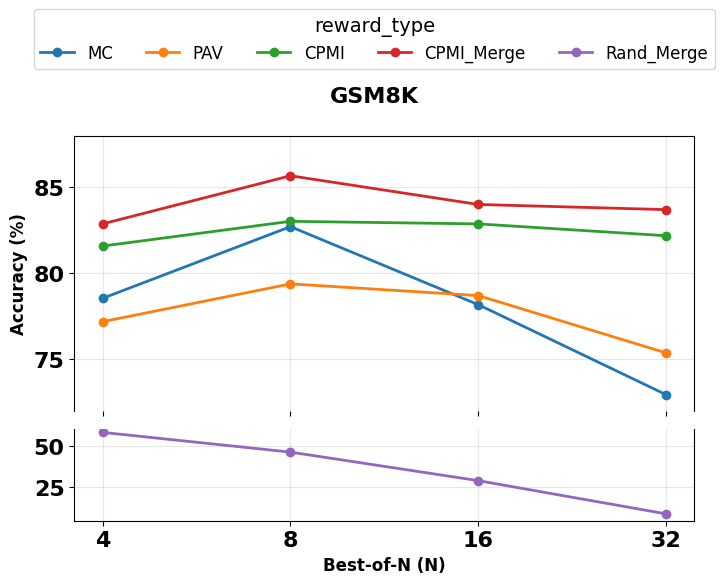

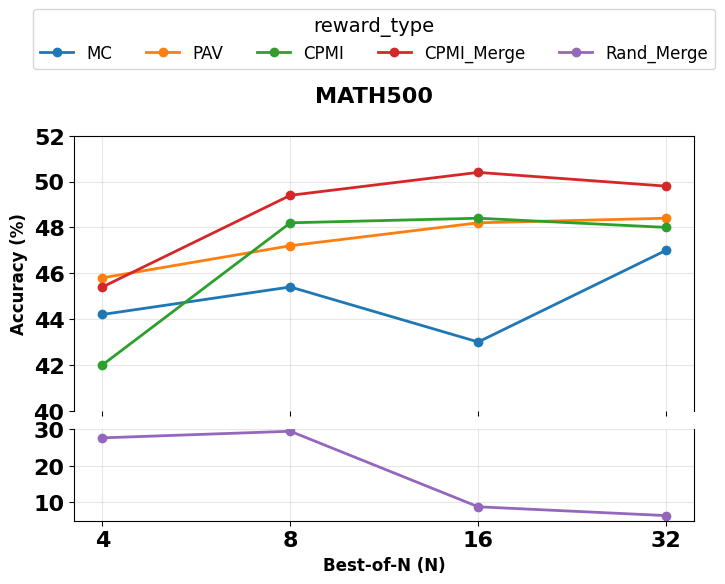

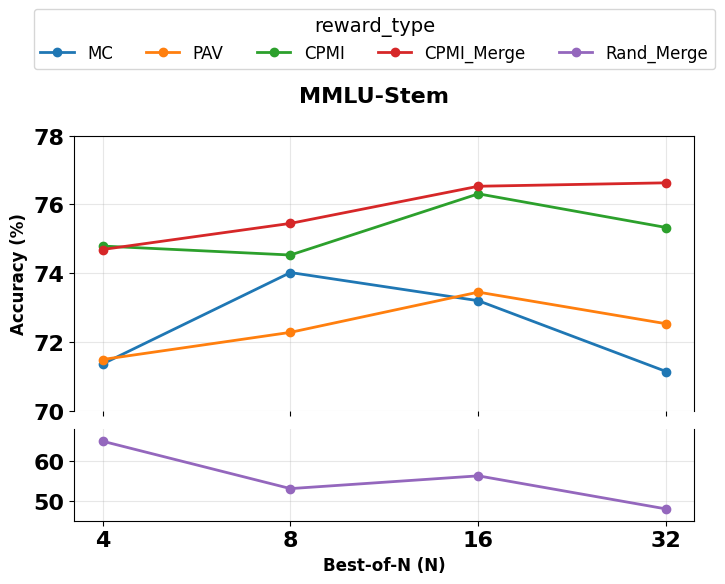

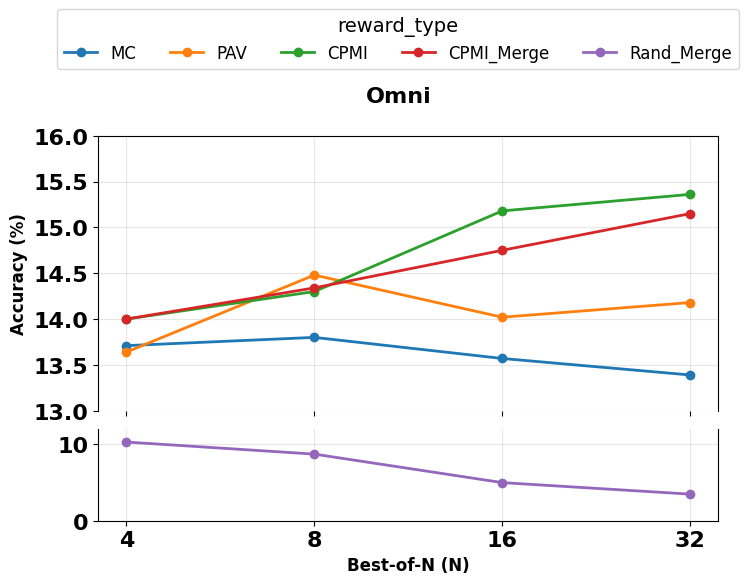

In [10]:
import matplotlib.pyplot as plt
import numpy as np

def add_wavy_break(ax_top, ax_bottom, x_center=0.5, width=0.6, amp=0.03, n_waves=2, lw=1.8):
    x0 = x_center - width / 2
    x1 = x_center + width / 2
    xs = np.linspace(x0, x1, 200)
    # 위쪽 축: 아래쪽 가장자리를 기준으로 살짝 아래로 내려서 그리기
    phase = np.linspace(0, n_waves * np.pi, 200)
    ys_top = -amp + amp * np.sin(phase)
    ax_top.plot(xs, ys_top, transform=ax_top.transAxes, clip_on=False, color="k", lw=lw)
    # 아래쪽 축: 위쪽 가장자리를 기준으로 살짝 위로 올려서 그리기
    ys_bot = 1 + amp * np.sin(phase)
    ax_bottom.plot(xs, ys_bot, transform=ax_bottom.transAxes, clip_on=False, color="k", lw=lw)

Ns = [4, 8, 16, 32]
pos_map   = {N: i for i, N in enumerate(Ns)}
positions = list(range(len(Ns)))
reward_types = ["MC", "PAV", "CPMI"]

data = {
    "GSM8K": {
        "MC":          {4: 78.54, 8: 82.71, 16: 78.17, 32: 72.93},
        "PAV":         {4: 77.18, 8: 79.38, 16: 78.70, 32: 75.36},
        "CPMI":        {4: 81.58, 8: 83.02, 16: 82.87, 32: 82.18},
        "CPMI_Merge":  {4: 82.87, 8: 85.67, 16: 84.0,  32: 83.7},
        "Rand_Merge":{4: 58.0,  8: 46.17,16: 29.04, 32: 9.1},
    },
    "MATH500": {
        "MC":          {4: 44.2,  8: 45.4, 16: 43.0, 32: 47.0},
        "PAV":         {4: 45.8,  8: 47.2, 16: 48.2, 32: 48.4},
        "CPMI":        {4: 42.0,  8: 48.2, 16: 48.4, 32: 48.0},
        "CPMI_Merge":  {4: 45.4,  8: 49.4, 16: 50.4, 32: 49.8},
        "Rand_Merge":{4: 27.6,  8: 29.4, 16: 8.8,  32: 6.4},
    },
    "MMLU-Stem": {
        "MC":          {4: 71.36, 8: 74.02, 16: 73.20, 32: 71.14},
        "PAV":         {4: 71.49, 8: 72.28, 16: 73.45, 32: 72.53},
        "CPMI":        {4: 74.79, 8: 74.53, 16: 76.31, 32: 75.33},
        "CPMI_Merge":  {4: 74.69, 8: 75.45, 16: 76.53, 32: 76.63},
        "Rand_Merge":{4: 64.95, 8: 53.06, 16: 56.26, 32: 47.95},
    },
    "Omni": {
        "MC":          {4: 13.71, 8: 13.80, 16: 13.57, 32: 13.39},
        "PAV":         {4: 13.64, 8: 14.48, 16: 14.02, 32: 14.18},
        "CPMI":        {4: 14.0,  8: 14.30, 16: 15.18, 32: 15.36},
        "CPMI_Merge":  {4: 14.0,  8: 14.34, 16: 14.75, 32: 15.15},
        "Rand_Merge":{4: 10.3,  8: 8.72, 16: 4.99, 32: 3.48},
    },
}

# 각 reward_type별 고정 색 (위/아래 축 모두 동일하게 쓰기 위함)
colors = {
    "MC": "C0",
    "PAV": "C1",
    "CPMI": "C2",
    "CPMI_Merge": "C3",
    "Rand_Merge": "C4",  # 보라색
}

# y축 범위 (필요하면 조정)
break_config = {
    "GSM8K":     {"bottom_ylim": (5, 60),  "top_ylim": (72, 88)},
    "MATH500":   {"bottom_ylim": (5, 30),  "top_ylim": (40, 52)},
    "MMLU-Stem": {"bottom_ylim": (45, 68), "top_ylim": (70, 78)},
    "Omni":      {"bottom_ylim": (0, 12),  "top_ylim": (13, 16)},
}

for dataset, rw_dict in data.items():
    fig, (ax_top, ax_bottom) = plt.subplots(
        2, 1, sharex=True, figsize=(8, 5),
        gridspec_kw={"height_ratios": [3, 1]},
    )

    # ==== 위쪽 축: MC, PAV, CPMI, CPMI_Merge ====
    for rw in ["MC", "PAV", "CPMI", "CPMI_Merge"]:
        xs = [pos_map[N] for N in Ns]
        ys = [rw_dict[rw][N] for N in Ns]
        ax_top.plot(xs, ys, marker="o", linewidth=2, label=rw, color=colors[rw])

    # ==== 아래쪽 축: Random_Merge만 ====
    xs_rm = [pos_map[N] for N in Ns]
    ys_rm = [rw_dict["Rand_Merge"][N] for N in Ns]
    ax_bottom.plot(xs_rm, ys_rm, marker="o", linewidth=2, label="Rand_Merge", color=colors["Rand_Merge"])

    cfg = break_config[dataset]
    ax_bottom.set_ylim(*cfg["bottom_ylim"])
    ax_top.set_ylim(*cfg["top_ylim"])

    # 축 끊기 표현
    ax_top.spines["bottom"].set_visible(False)
    ax_bottom.spines["top"].set_visible(False)
    ax_top.tick_params(labeltop=False)

    # x축 위치 / 라벨
    ax_bottom.set_xticks(positions)
    ax_bottom.set_xticklabels(Ns, fontsize=16, fontweight="bold")

    for ax in (ax_top, ax_bottom):
        ax.tick_params(axis="y", labelsize=16)
        for lab in ax.get_yticklabels():
            lab.set_fontweight("bold")

    fig.suptitle(dataset, fontsize=16, fontweight="bold")
    ax_top.set_ylabel("Accuracy (%)", fontsize=12, fontweight="bold")
    ax_bottom.set_xlabel("Best-of-N (N)", fontsize=12, fontweight="bold")

    ax_top.grid(True, alpha=0.3)
    ax_bottom.grid(True, alpha=0.3)

    # legend: 위쪽에서 위/아래 축 둘 다 합쳐서 한 번만
    h1, l1 = ax_top.get_legend_handles_labels()
    h2, l2 = ax_bottom.get_legend_handles_labels()
    fig.legend(
        h1 + h2,
        l1 + l2,
        title="reward_type",
        fontsize=12,
        title_fontsize=14,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.15),
        ncol=len(h1 + h2),
    )

    fig.subplots_adjust(hspace=0.1)
    plt.show()


## prompt template

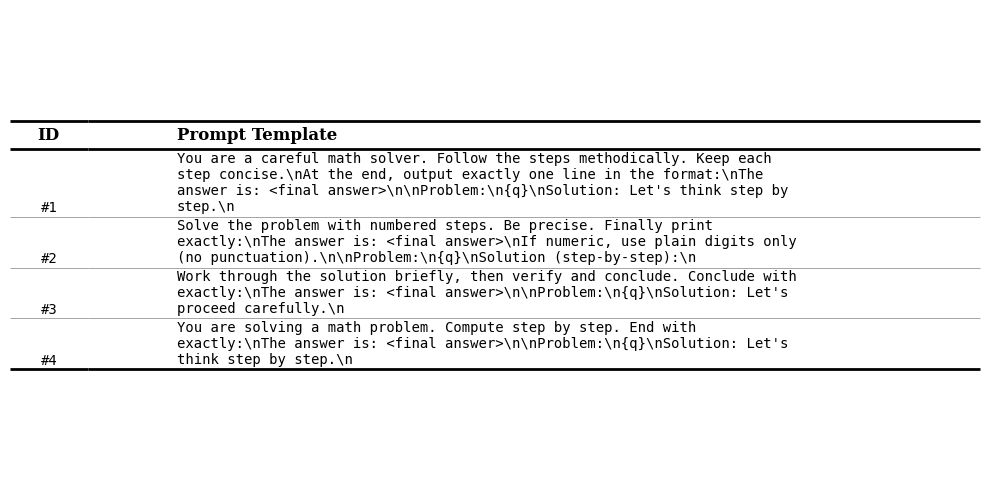

In [11]:
import matplotlib.pyplot as plt
import pandas as pd
from textwrap import wrap

# Define the prompts exactly as transcribed from the user's image
prompts = [
    (1, "You are a careful math solver. Follow the steps methodically. Keep each step concise.\\nAt the end, output exactly one line in the format:\\nThe answer is: <final answer>\\n\\nProblem:\\n{q}\\nSolution: Let's think step by step.\\n"),
    (2, "Solve the problem with numbered steps. Be precise. Finally print exactly:\\nThe answer is: <final answer>\\nIf numeric, use plain digits only (no punctuation).\\n\\nProblem:\\n{q}\\nSolution (step-by-step):\\n"),
    (3, "Work through the solution briefly, then verify and conclude. Conclude with exactly:\\nThe answer is: <final answer>\\n\\nProblem:\\n{q}\\nSolution: Let's proceed carefully.\\n"),
    (4, "You are solving a math problem. Compute step by step. End with exactly:\\nThe answer is: <final answer>\\n\\nProblem:\\n{q}\\nSolution: Let's think step by step.\\n")
]

# Create a figure and axis
fig, ax = plt.subplots(figsize=(10, 5)) # Width, Height (adjusted dynamically below usually, but fixed here)

# Hide axes
ax.xaxis.set_visible(False)
ax.yaxis.set_visible(False)
ax.set_frame_on(False)

# Prepare data for the table
table_data = []
for idx, text in prompts:
    # Wrap text for the image table so it doesn't run off
    # We simulate the display of the raw string, keeping \n visible as requested by the context of "prompts"
    # But for visual clarity in a table image, we break lines visually
    wrapped_text = "\n".join(wrap(text, width=80)) 
    table_data.append([f"#{idx}", text])

# Column labels
col_labels = ["ID", "Prompt Template"]

# Create the table
table = plt.table(cellText=table_data, colLabels=col_labels, loc='center', cellLoc='left')

# Style the table to look like an academic paper table (Booktabs style)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.5) # Increase row height to accommodate text wrapping if we were doing auto-wrap, but here we need manual adjust

# Manual formatting for "pretty" academic look
for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor('black')
    cell.set_linewidth(0) # Remove default grid
    
    # Text properties
    if row == 0:
        cell.set_text_props(weight='bold', fontfamily='serif')
        cell.set_linewidth(1.5) # Thicker line for header
        cell.set_edgecolor('black')
        # Add bottom border to header
        cell.visible_edges = "B" 
    else:
        cell.set_text_props(fontfamily='monospace') # Code-like font for prompts
        # Add weak separator lines between rows
        if row < len(prompts): 
             cell.visible_edges = "B"
             cell.set_linewidth(0.5)
             cell.set_edgecolor('#d3d3d3') # Light gray separators
    
    # Add top and bottom heavy lines (Header top, Table bottom)
    if row == 0:
        cell.visible_edges = "TB"
        cell.set_linewidth(1.5)
    if row == len(prompts):
        cell.visible_edges = "B"
        cell.set_linewidth(1.5)

    # Column widths
    if col == 0:
        cell.set_width(0.08)
    else:
        cell.set_width(0.92)
        # Apply wrapping manually to the cell text object if needed, 
        # but matplotlib table text doesn't auto-wrap nicely.
        # We will use the 'textwrap' library on the input strings.
        
# Re-do data with explicit wrapping for the figure rendering
import textwrap
wrapped_data = []
for idx, text in prompts:
    # Break the text into lines of length ~75 characters
    lines = textwrap.wrap(text, width=75)
    formatted_text = "\n".join(lines)
    wrapped_data.append([f"#{idx}", formatted_text])

# Clear previous table and redraw with wrapped text
ax.clear()
ax.xaxis.set_visible(False)
ax.yaxis.set_visible(False)
ax.set_frame_on(False)

table = plt.table(cellText=wrapped_data, colLabels=col_labels, loc='center', cellLoc='left')
table.auto_set_font_size(False)
table.set_fontsize(11)

# Adjust scaling
# Calculate row heights based on number of lines
row_height_base = 0.04
for (row, col), cell in table.get_celld().items():
    cell.set_linewidth(0) 
    
    if row == 0:
        cell.set_height(0.06)
        cell.set_text_props(weight='bold', fontfamily='serif', size=12)
        cell.visible_edges = "TB"
        cell.set_linewidth(2)
    else:
        # Calculate lines in this cell
        content = wrapped_data[row-1][col]
        num_lines = content.count('\n') + 1
        cell.set_height(row_height_base * num_lines * 0.9) # Dynamic height
        cell.set_text_props(fontfamily='monospace', size=10)
        
        # Border logic
        if row == len(prompts):
            cell.visible_edges = "B"
            cell.set_linewidth(2)
        else:
            cell.visible_edges = "B"
            cell.set_linewidth(0.5)
            cell.set_edgecolor('gray')

    # Column widths
    if col == 0:
        cell.set_width(0.08)
        cell.set_text_props(ha='center') # Center ID
    else:
        cell.set_width(0.92)
        cell.set_text_props(ha='left')   # Left align prompts
        # Add some padding to text
        # Matplotlib table cells don't have easy padding, relying on height scaling

plt.tight_layout()
plt.savefig('prompt_diversification_table.jpg', dpi=300, bbox_inches='tight')

## ablation M

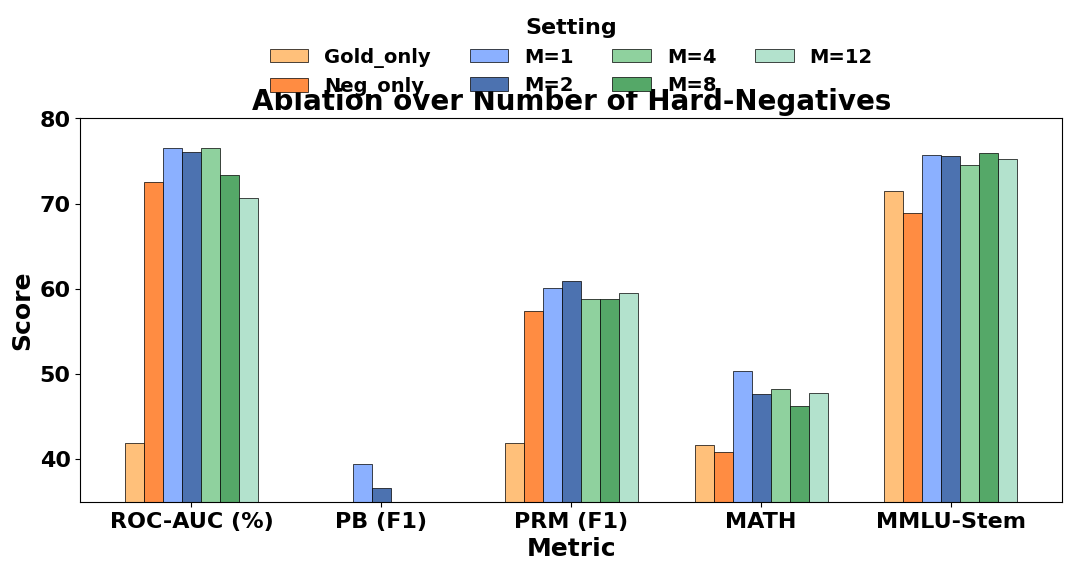

In [3]:
import numpy as np
import matplotlib.pyplot as plt

methods = ["Gold_only", "Neg_only", "M=1", "M=2", "M=4", "M=8", "M=12"]
metrics = ["ROC-AUC (%)", "PB (F1)", "PRM (F1)", "MATH", "MMLU-Stem"]

values = np.array([
    [0.419, 15.53, 41.85, 41.6, 71.52],  # gold_only
    [0.725, 24.65, 57.42, 40.8, 68.92],  # neg_only
    [0.765, 39.48, 60.04, 50.4, 75.67],  # m=1
    [0.761, 36.60, 60.85, 47.6, 75.55],  # m=2
    [0.765, 34.58, 58.75, 48.2, 74.53],  # m=4
    [0.733, 31.35, 58.78, 46.2, 75.93],  # m=8
    [0.707, 30.45, 59.46, 47.8, 75.20],  # m=12
])

# ROC-AUC를 %로 변환
values[:, 0] *= 100.0

num_methods = len(methods)
num_metrics = len(metrics)

x = np.arange(num_metrics)
bar_width = 0.1

plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 20,
    "axes.labelsize": 18,
    "legend.fontsize": 14,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
})

fig, ax = plt.subplots(figsize=(11, 6))

# 색 팔레트: Gold/Neg는 오렌지 계열, 나머지는 파랑/초록 계열 파스텔 느낌
colors = [
    "#FFC07A",  # Gold_only (pastel orange)
    "#FF8C42",  # Neg_only (stronger orange)
    "#8BB0FF",  # M=1 (light blue)
    "#4C72B0",  # M=2 (blue)
    "#8FD19E",  # M=4 (light green)
    "#55A868",  # M=8 (green)
    "#B3E2CD",  # M=12 (very light mint)
]

for i, method in enumerate(methods):
    offset = (i - num_methods / 2) * bar_width + bar_width / 2
    ax.bar(
        x + offset,
        values[i],
        width=bar_width,
        label=method,
        color=colors[i],
        edgecolor="black",
        linewidth=0.5,
    )

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontweight="bold")
ax.set_ylabel("Score", fontweight="bold")
ax.set_xlabel("Metric", fontweight="bold")
ax.set_title("Ablation over Number of Hard-Negatives", fontweight="bold")

# 약간 위아래만 잘라서 차이가 더 보이게 (값 범위 40~80 근처라 거기 맞춤)
ax.set_ylim(35, 80)

for label in ax.get_yticklabels():
    label.set_fontweight("bold")

# legend를 위쪽 바깥으로 빼기
leg = ax.legend(
    title="Setting",
    frameon=False,
    ncol=4,
    loc="lower center",
    bbox_to_anchor=(0.5, 1.01)
)
leg.get_title().set_fontweight("bold")
for txt in leg.get_texts():
    txt.set_fontweight("bold")

plt.tight_layout()
plt.show()


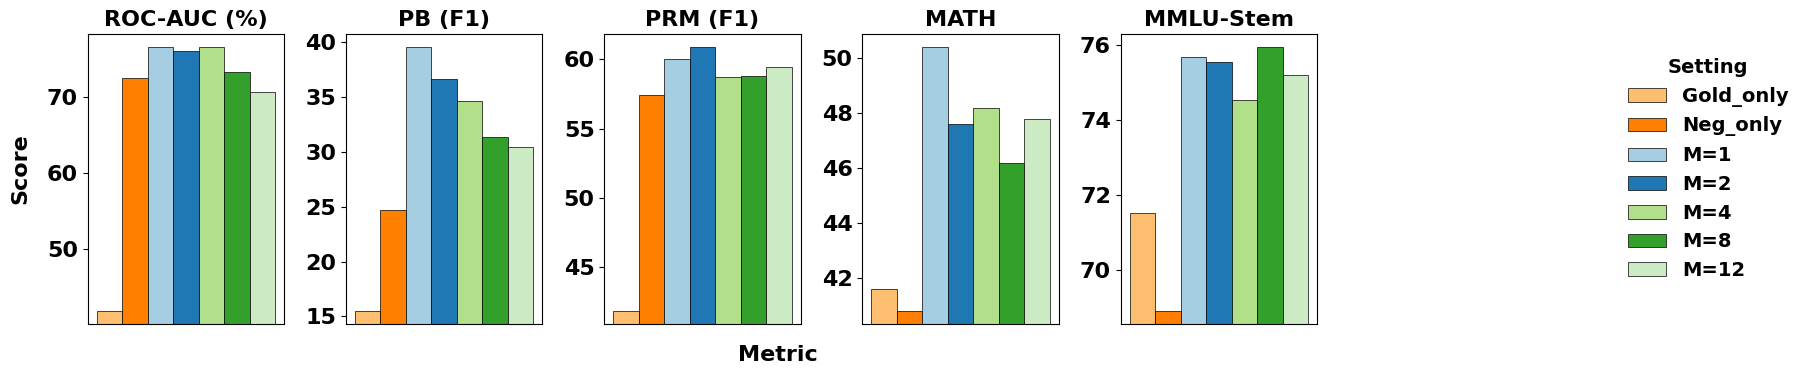

In [7]:
import numpy as np
import matplotlib.pyplot as plt

methods = ["Gold_only", "Neg_only", "M=1", "M=2", "M=4", "M=8", "M=12"]
metrics = ["ROC-AUC (%)", "PB (F1)", "PRM (F1)", "MATH", "MMLU-Stem"]

values = np.array([
    [0.419, 15.53, 41.85, 41.6, 71.52],
    [0.725, 24.65, 57.42, 40.8, 68.92],
    [0.765, 39.48, 60.04, 50.4, 75.67],
    [0.761, 36.60, 60.85, 47.6, 75.55],
    [0.765, 34.58, 58.75, 48.2, 74.53],
    [0.733, 31.35, 58.78, 46.2, 75.93],
    [0.707, 30.45, 59.46, 47.8, 75.20],
])

# ROC-AUC → %
values[:, 0] *= 100.0

# 색 팔레트: Gold/Neg = 오렌지, 나머지는 파랑/초록 계열
colors = [
    "#FDBF6F",  # Gold_only  (pastel orange)
    "#FF7F00",  # Neg_only   (strong orange)
    "#A6CEE3",  # M=1        (light blue)
    "#1F78B4",  # M=2        (blue)
    "#B2DF8A",  # M=4        (light green)
    "#33A02C",  # M=8        (green)
    "#CCEBC5",  # M=12       (very light green)
]

plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
})

fig, axes = plt.subplots(1, len(metrics), figsize=(16, 4), sharey=False)

bar_width = 0.9 / len(methods)
x = np.arange(1)   # 각 subplot에 x=0 하나만

# 각 metric별 y축 범위를 데이터 기반으로 자동 설정
y_lims = {}
for j, metric in enumerate(metrics):
    col = values[:, j]
    ymin, ymax = col.min(), col.max()
    margin = 0.05 * (ymax - ymin if ymax > ymin else 1.0)
    y_lims[metric] = (ymin - margin, ymax + margin)

for j, metric in enumerate(metrics):
    ax = axes[j]
    for i, method in enumerate(methods):
        offset = (i - len(methods) / 2) * bar_width + bar_width / 2
        ax.bar(
            x + offset,
            values[i, j],
            width=bar_width,
            color=colors[i],
            edgecolor="black",
            linewidth=0.5,
        )
    ax.set_title(metric, fontweight="bold")
    ax.set_xticks([])
    ax.set_ylim(*y_lims[metric])
    for label in ax.get_yticklabels():
        label.set_fontweight("bold")

# 공통 축 라벨
fig.text(0.5, 0.02, "Metric", ha="center",
         fontsize=16, fontweight="bold")
fig.text(0.02, 0.5, "Score", va="center",
         rotation="vertical", fontsize=16, fontweight="bold")

# legend: 오른쪽에 1열로 배치
handles = [
    plt.Rectangle((0, 0), 1, 1, color=c, ec="black", lw=0.5)
    for c in colors
]
leg = fig.legend(
    handles,
    methods,
    title="Setting",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    ncol=1,
    frameon=False,
)
leg.get_title().set_fontweight("bold")
for txt in leg.get_texts():
    txt.set_fontweight("bold")

# 오른쪽에 legend 자리 확보
plt.tight_layout(rect=[0.03, 0.05, 0.85, 0.95])
plt.show()


# Efficiency

In [107]:
import pandas as pd
import matplotlib.pyplot as plt

switch = [0, 1, 2, 3, 4]
auc_cmi        = [0.6625, 0.6039, 0.6809, 0.7344, 0.7714]
auc_contr_marg = [0.6616, 0.7912, 0.8374, 0.8590, 0.8724]
auc_pll_cmi    = [0.6032, 0.6535, 0.7361, 0.7936, 0.8239]
auc_qval_max   = 0.8849

cost_cmi        = [1.46, 17.8, 34.2, 48.8, 60.3]
cost_pll_cmi    = [5.92, 21.5, 37.2, 51.1, 62.1]
cost_contr_marg = [8.87, 24.0, 39.1, 52.6, 63.3]

def eff_percent(acc_list, cost_list, acc_qval=auc_qval_max):
    base = acc_qval / 100.0
    return [(a / max(c, 1e-9)) / base * 100.0 for a, c in zip(acc_list, cost_list)]

eff_cmi        = eff_percent(auc_cmi, cost_cmi)
eff_pll_cmi    = eff_percent(auc_pll_cmi, cost_pll_cmi)
eff_contr_marg = eff_percent(auc_contr_marg, cost_contr_marg)

df = pd.DataFrame({
    "switch_at": switch,
    "AUC_cmi": auc_cmi,
    "AUC_pll_cmi": auc_pll_cmi,
    "AUC_contr_marg": auc_contr_marg,
    "Cost%_cmi": cost_cmi,
    "Cost%_pll_cmi": cost_pll_cmi,
    "Cost%_contr_marg": cost_contr_marg,
    "Eff%_cmi": eff_cmi,
    "Eff%_pll_cmi": eff_pll_cmi,
    "Eff%_contr_marg": eff_contr_marg,
})
print("Mixing efficiency summary", df)

# Pareto scatter
plt.figure(figsize=(6,5))
plt.scatter(cost_cmi, auc_cmi, label="CMI")
plt.scatter(cost_pll_cmi, auc_pll_cmi, label="PLL-CMI (E=4)")
plt.scatter(cost_contr_marg, auc_contr_marg, label="Contrastive Marginal (M≈5)")
for i in [0, 4]:
    plt.annotate(f"s={switch[i]}", (cost_cmi[i], auc_cmi[i]))
    plt.annotate(f"s={switch[i]}", (cost_pll_cmi[i], auc_pll_cmi[i]))
    plt.annotate(f"s={switch[i]}", (cost_contr_marg[i], auc_contr_marg[i]))
plt.axhline(auc_qval_max, linestyle="--", linewidth=1)
plt.xlabel("Cost (% of qval)")
plt.ylabel("ROC-AUC")
plt.title("Pareto: Cost vs Accuracy (switch_at sweep)")
plt.legend()
plt.tight_layout()
pareto_path = "./pareto_cost_auc.png"
plt.savefig(pareto_path, dpi=160)
plt.close()

# Cost vs switch
plt.figure(figsize=(6,4))
plt.plot(switch, cost_cmi, marker="o", label="CMI")
plt.plot(switch, cost_pll_cmi, marker="o", label="PLL-CMI (E=4)")
plt.plot(switch, cost_contr_marg, marker="o", label="Contrastive Marginal (M≈5)")
plt.xlabel("switch_at (qval ratio ↑)")
plt.ylabel("Total Cost (% of qval)")
plt.title("Total Cost vs switch_at")
plt.legend()
plt.tight_layout()
cost_path = "./cost_vs_switch.png"
plt.savefig(cost_path, dpi=160)
plt.close()

# Efficiency vs switch (× vs qval)
plt.figure(figsize=(6,4))
plt.plot(switch, [e/100.0 for e in eff_cmi], marker="o", label="CMI")
plt.plot(switch, [e/100.0 for e in eff_pll_cmi], marker="o", label="PLL-CMI (E=4)")
plt.plot(switch, [e/100.0 for e in eff_contr_marg], marker="o", label="Contrastive Marginal (M≈5)")
plt.xlabel("switch_at")
plt.ylabel("Efficiency (× vs qval)")
plt.title("Efficiency Gain vs switch_at")
plt.legend()
plt.tight_layout()
eff_path = "./eff_vs_switch.png"
plt.savefig(eff_path, dpi=160)
plt.close()

pareto_path, cost_path, eff_path


Mixing efficiency summary    switch_at  AUC_cmi  AUC_pll_cmi  AUC_contr_marg  Cost%_cmi  Cost%_pll_cmi  \
0          0   0.6625       0.6032          0.6616       1.46           5.92   
1          1   0.6039       0.6535          0.7912      17.80          21.50   
2          2   0.6809       0.7361          0.8374      34.20          37.20   
3          3   0.7344       0.7936          0.8590      48.80          51.10   
4          4   0.7714       0.8239          0.8724      60.30          62.10   

   Cost%_contr_marg     Eff%_cmi  Eff%_pll_cmi  Eff%_contr_marg  
0              8.87  5127.891550   1151.450920       842.903159  
1             24.00   383.398873    343.489082       372.546804  
2             39.10   224.989905    223.614357       242.025989  
3             52.60   170.066452    175.503816       184.549649  
4             63.30   144.566653    149.930058       155.746305  


('./pareto_cost_auc.png', './cost_vs_switch.png', './eff_vs_switch.png')